# TAI* — Evolutionary Age Index Pipeline
### Nematostella vectensis vs. Hydra vulgaris

This notebook is a clean rewrite of the analysis pipeline: same results,
much simpler code, and a plain-language explanation before each step.

**What this notebook does, in order:**
1. Load both species' single-cell atlases
2. Build a gene-age ("phylostratum") score for each gene, using orthology data
3. Compute the classical age index (TAI) and our improved version (TAI*)
4. Compare the two, and check the results aren't driven by one dominant gene
5. Compare cell types *across* species using only clean, unambiguous 1:1 orthologs

No step here is "magic" — every function does one clear thing, and is named
for what it does.


## 0. Setup

Fill in the four paths below once — everything else in this notebook reuses them.


In [1]:
import scanpy as sc
import skimage
print("scikit-image:", skimage.__version__)
print("scanpy:", sc.__version__)

scikit-image: 0.26.0
scanpy: 1.10.2


In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ---- EDIT THESE FOUR PATHS ----
ORTHOGROUPS_FILE = "Orthogroups.tsv"          # from OrthoFinder
NVE_TO_REFSEQ_FILE = "nve_to_refseq_hits.tsv"  # Diamond blastx output, Nematostella side
HYDRA_TO_REFSEQ_FILE = "hydra_to_refseq_hits-Copy1.tsv"  # Diamond blastp output, Hydra side
GENE_LOOKUP_EXCEL = "12983_2024_529_MOESM3_ESM.xlsx"     # the paper's genes.LUT sheet

NEMATOSTELLA_H5AD = "nematostella_raw_atlas.h5ad"   # your annotated Nematostella object
HYDRA_H5AD = "hydra_single_cell_annotated.h5ad"                 # your annotated Hydra object


## 1. Load the orthology data

We need three simple lookup tables:

- **Orthogroups**: which genes, from which species, are considered "the same gene family"
- **Nematostella gene ID bridge**: our atlas uses one gene-naming system (NV2), OrthoFinder
  used another (RefSeq) — this bridges the two
- **Hydra gene ID bridge**: same idea, for Hydra's gene names


In [2]:
# Orthogroups: one row per gene family, one column per species
orthogroups = pd.read_csv(ORTHOGROUPS_FILE, sep="\t")
print(f"Loaded {len(orthogroups)} orthogroups across species: {orthogroups.columns.tolist()}")

# Nematostella: NV2 (atlas) -> NVE (gene model) -> RefSeq (used in orthology search)
gene_lookup = pd.read_excel(GENE_LOOKUP_EXCEL, sheet_name="genes.LUT")
nv2_to_nve = (
    gene_lookup.set_index("geneID")["NVE"]
    .dropna()
    .loc[lambda s: s != "-"]
    .apply(lambda x: str(x).split(",")[0].strip())  # some genes map to >1 old ID; keep the first
    .to_dict()
)

nve_to_refseq = (
    pd.read_csv(NVE_TO_REFSEQ_FILE, sep="\t", header=None,
                names=["query", "refseq", "pident", "length", "mismatch", "gapopen",
                       "qstart", "qend", "sstart", "send", "evalue", "bitscore"])
    .set_index("query")["refseq"]
    .to_dict()
)

# Hydra: Augustus gene ID -> RefSeq
hydra_to_refseq = (
    pd.read_csv(HYDRA_TO_REFSEQ_FILE, sep="\t", header=None,
                names=["query", "refseq", "pident", "length", "mismatch", "gapopen",
                       "qstart", "qend", "sstart", "send", "evalue", "bitscore"])
    .set_index("query")["refseq"]
    .to_dict()
)

print(f"NV2->NVE bridge: {len(nv2_to_nve)} genes")
print(f"NVE->RefSeq bridge: {len(nve_to_refseq)} genes")
print(f"Hydra->RefSeq bridge: {len(hydra_to_refseq)} genes")


Loaded 10762 orthogroups across species: ['Orthogroup', 'Dmel', 'Drer', 'Hvul', 'Nvec', 'Scer']
NV2->NVE bridge: 18056 genes
NVE->RefSeq bridge: 22105 genes
Hydra->RefSeq bridge: 28081 genes


## 2. Assign an "age" to every gene

**The idea:** for each gene, look across our panel of reference species
(Hydra/Nematostella, Drosophila, Zebrafish, Yeast) and ask — *how far back can
I still find a related gene?* That distance is the gene's **phylostratum**:

- Found only next to its closest relative → young gene (small number)
- Found all the way out to yeast → ancient gene (large number)

We also count **paralogs** (how many copies of this gene family exist) — this
feeds into TAI*, our extension of the classical index.


In [3]:
def build_gene_age_table(orthogroups, focal_species_col, reference_ladder):
    """
    For every gene in `focal_species_col`, find the deepest reference species
    (from `reference_ladder`, ordered near -> far) where a related gene exists.

    Returns two dictionaries, keyed by RefSeq ID:
      - age:      how far back this gene's ancestry can be traced (bigger = older)
      - n_copies: how many paralogs (copies) this gene has in the focal species
    """
    age = {}
    n_copies = {}
    for _, row in orthogroups.iterrows():
        if pd.isna(row[focal_species_col]):
            continue
        genes_in_group = [g.strip() for g in str(row[focal_species_col]).split(",")]

        deepest_reference_found = 0
        for depth, reference_species in enumerate(reference_ladder, start=1):
            if reference_species in orthogroups.columns and pd.notna(row[reference_species]):
                deepest_reference_found = depth

        for gene in genes_in_group:
            age[gene] = deepest_reference_found
            n_copies[gene] = len(genes_in_group)

    return age, n_copies


# Nematostella's age is measured against: Hydra (closest) -> Fly -> Fish -> Yeast (farthest)
nv_age, nv_copies = build_gene_age_table(
    orthogroups, focal_species_col="Nvec",
    reference_ladder=["Hvul", "Dmel", "Drer", "Scer"]
)

# Hydra's age is measured against: Nematostella (closest) -> Fly -> Fish -> Yeast
hy_age, hy_copies = build_gene_age_table(
    orthogroups, focal_species_col="Hvul",
    reference_ladder=["Nvec", "Dmel", "Drer", "Scer"]
)

print(f"Nematostella genes with an age assigned: {len(nv_age)}")
print(f"Hydra genes with an age assigned: {len(hy_age)}")


Nematostella genes with an age assigned: 16323
Hydra genes with an age assigned: 20337


## 3. Bridge gene ages onto each species' actual atlas gene names

The age table above is keyed by RefSeq ID. Our single-cell atlases use
different gene-naming systems (NV2 for Nematostella, Augustus IDs for Hydra),
so we translate the age table into each atlas's own gene names.


In [4]:
def translate_age_table(age_dict, copies_dict, bridge_dict):
    """
    Convert a RefSeq-keyed age/copy-count table into one keyed by whatever
    gene names `bridge_dict` maps TO refseq IDs.
    """
    translated_age = {}
    translated_copies = {}
    for atlas_gene, refseq_id in bridge_dict.items():
        if refseq_id in age_dict:
            translated_age[atlas_gene] = age_dict[refseq_id]
            translated_copies[atlas_gene] = copies_dict[refseq_id]
    return translated_age, translated_copies


# Nematostella: chain NV2 -> NVE -> RefSeq -> age
nv2_to_refseq = {nv2: nve_to_refseq[nve] for nv2, nve in nv2_to_nve.items() if nve in nve_to_refseq}
nv_age_by_nv2, nv_copies_by_nv2 = translate_age_table(nv_age, nv_copies, nv2_to_refseq)

# Hydra: Augustus gene ID -> RefSeq -> age
hy_age_by_augustus, hy_copies_by_augustus = translate_age_table(hy_age, hy_copies, hydra_to_refseq)

print(f"Nematostella atlas genes with age assigned: {len(nv_age_by_nv2)}")
print(f"Hydra atlas genes with age assigned: {len(hy_age_by_augustus)}")


# NOTE: if your Nematostella object's genes are ALREADY named with NVE-style IDs
# (e.g. loaded from the 16-sample pooled/relabeled atlas rather than the 4-sample
# one), skip the NV2 step entirely and bridge straight from NVE -> RefSeq -> age:
nv_age_by_nve, nv_copies_by_nve = translate_age_table(nv_age, nv_copies, nve_to_refseq)
print(f"Nematostella genes with age assigned (NVE-keyed): {len(nv_age_by_nve)}")


Nematostella atlas genes with age assigned: 10919
Hydra atlas genes with age assigned: 21476
Nematostella genes with age assigned (NVE-keyed): 14452


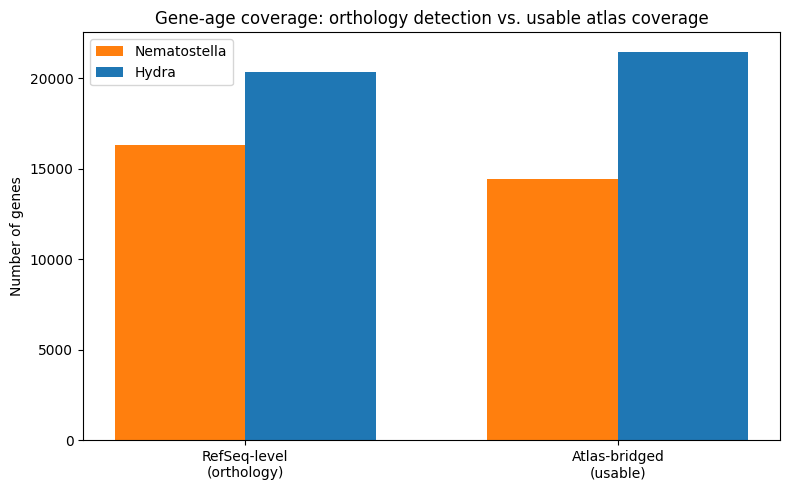

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['RefSeq-level\n(orthology)', 'Atlas-bridged\n(usable)']
nv_vals = [len(nv_age), len(nv_age_by_nve)]
hy_vals = [len(hy_age), len(hy_age_by_augustus)]

x = range(len(categories))
width = 0.35
ax.bar([i - width/2 for i in x], nv_vals, width, label='Nematostella', color='#ff7f0e')
ax.bar([i + width/2 for i in x], hy_vals, width, label='Hydra', color='#1f77b4')
ax.set_xticks(list(x)); ax.set_xticklabels(categories)
ax.set_ylabel('Number of genes')
ax.set_title('Gene-age coverage: orthology detection vs. usable atlas coverage')
ax.legend()
plt.tight_layout()
plt.show()

## 4. The TAI formulas

**Classical TAI** — for a group of cells, take a weighted average of each
gene's age, weighted by how much that gene is expressed:

$$TAI = \frac{\sum_i (\text{age}_i \times \text{expression}_i)}{\sum_i \text{expression}_i}$$

**TAI\*** — our extension. We additionally boost a gene's weight if it belongs
to a large gene family (more paralogs = more evidence of evolutionary
"innovation" through duplication), and we cap any single gene's contribution
so one very highly-expressed outlier can't distort the whole score.


In [6]:
def compute_tai(pseudobulk_expression, gene_age, max_single_gene_share=0.10, use_paralog_weight=None):
    """
    pseudobulk_expression: DataFrame, genes (rows) x cell types (columns)
    gene_age:              Series or dict, gene -> age score
    max_single_gene_share: no single gene may contribute more than this
                           fraction of a cell type's total score
    use_paralog_weight:    optional Series/dict, gene -> number of paralogs.
                           If given, computes TAI* instead of classical TAI.

    Returns one row per cell type: the age score, and how much the single
    biggest gene contributed (a red flag if this is high).
    """
    age_series = pd.Series(gene_age)
    if use_paralog_weight is not None:
        paralog_series = pd.Series(use_paralog_weight)
        weight = age_series * np.log2(1 + paralog_series.reindex(age_series.index).fillna(0))
    else:
        weight = age_series

    results = []
    for cell_type in pseudobulk_expression.columns:
        expr = pseudobulk_expression[cell_type]
        shared_genes = expr.index.intersection(weight.index)
        expr, w = expr.loc[shared_genes], weight.loc[shared_genes]

        if expr.sum() == 0:
            continue

        raw_contribution = expr * w
        total = raw_contribution.sum()
        capped_contribution = raw_contribution.clip(upper=max_single_gene_share * total)

        results.append({
            "cell_type": cell_type,
            "age_score": capped_contribution.sum() / expr.sum(),
            "biggest_single_gene_share": raw_contribution.max() / total if total > 0 else 0,
            "n_genes_used": len(shared_genes),
        })

    return pd.DataFrame(results).sort_values("age_score", ascending=False)


In [7]:
def build_pseudobulk(adata_obj, cell_type_column):
    """Sum raw counts across all cells of each cell type. Returns genes x cell-types."""
    counts_layer = adata_obj.layers["counts"] if "counts" in adata_obj.layers else adata_obj.X
    profiles = {}
    for cell_type in adata_obj.obs[cell_type_column].dropna().unique():
        mask = adata_obj.obs[cell_type_column] == cell_type
        summed = np.asarray(counts_layer[mask.values].sum(axis=0)).flatten()
        profiles[cell_type] = pd.Series(summed, index=adata_obj.var_names)
    return pd.DataFrame(profiles)

## 5. Build pseudobulk expression and run both indices

"Pseudobulk" just means: add up all the individual cells of one cell type into
a single combined expression profile, so we get one stable number per gene per
cell type instead of noisy single-cell values.


In [8]:
NEMATOSTELLA_CELL_TYPE_COLUMN = "Partition_ID"  # use "cell_type_short" if using the 4-sample object instead

adata_nv = ad.read_h5ad(NEMATOSTELLA_H5AD)
adata_hy = ad.read_h5ad(HYDRA_H5AD)

nv_pseudobulk = build_pseudobulk(adata_nv, cell_type_column=NEMATOSTELLA_CELL_TYPE_COLUMN)
hy_pseudobulk = build_pseudobulk(adata_hy, cell_type_column="siebert_cell_type")

print("Nematostella cell types:", nv_pseudobulk.columns.tolist())
print("Hydra cell types:", hy_pseudobulk.columns.tolist())


Nematostella cell types: ['gastrodermis', 'epithelia.ect', 'mat.cnido', 'neuroglandular', 'unchar.immune', 'neuronal', 'gland.mucous', 'pSC', 'PGCs', 'pharyngeal.ect', 'ectoderm.embryonic', 'mesendoderm.embryonic', 'cnidocyte', 'retractor muscle']
Hydra cell types: ['Interstitial Stem Cells (ISCs)', 'Nematoblasts (Progenitors)', 'Multipotent i-cell Stem Core', 'Multipotent Progenitors', 'Granular Mucous Gland Cells', 'Ectodermal Epithelial', 'Germline Progenitors', 'Endodermal Progenitors', 'Nematocytes (Stenotele/Desmoneme)', 'Basal Disk Epithelial', 'Zymogen Gland Cells', 'Ectodermal Progenitors', 'Neurons (Ganglion/Sensory)', 'Endodermal Stem Cells', 'Endodermal Epithelial', 'Tentacle Battery Cells', 'Ectodermal Stem Cells']


In [9]:
# --- Nematostella: classical TAI vs. TAI* ---
# Uses nv_age_by_nve / nv_copies_by_nve since this object's genes are already NVE IDs.
# (If using the 4-sample cell_type_short object instead, swap in nv_age_by_nv2 / nv_copies_by_nv2.)
nv_classical = compute_tai(nv_pseudobulk, nv_age_by_nve)
nv_star = compute_tai(nv_pseudobulk, nv_age_by_nve, use_paralog_weight=nv_copies_by_nve)

print("=== Nematostella: classical TAI ===")
print(nv_classical.to_string(index=False))
print("\n=== Nematostella: TAI* ===")
print(nv_star.to_string(index=False))


=== Nematostella: classical TAI ===
            cell_type  age_score  biggest_single_gene_share  n_genes_used
         gastrodermis   3.616287                   0.027743          7362
                  pSC   3.595054                   0.023329          7362
       pharyngeal.ect   3.564488                   0.020898          7362
        epithelia.ect   3.530600                   0.025327          7362
mesendoderm.embryonic   3.502249                   0.021093          7362
   ectoderm.embryonic   3.464866                   0.020608          7362
                 PGCs   3.449057                   0.013956          7362
         gland.mucous   3.440561                   0.042979          7362
        unchar.immune   3.424967                   0.019365          7362
       neuroglandular   3.424698                   0.026911          7362
     retractor muscle   3.423765                   0.142417          7362
             neuronal   3.419256                   0.022100          7362
  

In [10]:
# --- Hydra: classical TAI vs. TAI* ---
hy_classical = compute_tai(hy_pseudobulk, hy_age_by_augustus)
hy_star = compute_tai(hy_pseudobulk, hy_age_by_augustus, use_paralog_weight=hy_copies_by_augustus)

print("=== Hydra: classical TAI ===")
print(hy_classical.to_string(index=False))
print("\n=== Hydra: TAI* ===")
print(hy_star.to_string(index=False))


=== Hydra: classical TAI ===
                        cell_type  age_score  biggest_single_gene_share  n_genes_used
       Nematoblasts (Progenitors)   3.415907                   0.001336         11231
              Zymogen Gland Cells   3.374415                   0.001984         11231
      Granular Mucous Gland Cells   3.348536                   0.002260         11231
           Tentacle Battery Cells   3.328791                   0.003176         11231
            Basal Disk Epithelial   3.296828                   0.003458         11231
             Germline Progenitors   3.290121                   0.000790         11231
       Neurons (Ganglion/Sensory)   3.280750                   0.002131         11231
   Interstitial Stem Cells (ISCs)   3.272137                   0.001627         11231
Nematocytes (Stenotele/Desmoneme)   3.257790                   0.002012         11231
            Ectodermal Epithelial   3.255215                   0.001141         11231
           Endodermal Pro

In [11]:
# Rebuild the raw (uncapped) contribution breakdown for retractor muscle specifically
def show_top_drivers(pseudobulk_expression, gene_age, gene_paralogs, cell_type, top_n=10):
    age_series = pd.Series(gene_age)
    paralog_series = pd.Series(gene_paralogs)
    weight = age_series * np.log2(1 + paralog_series.reindex(age_series.index).fillna(0))
    
    expr = pseudobulk_expression[cell_type]
    shared = expr.index.intersection(weight.index)
    expr, w = expr.loc[shared], weight.loc[shared]
    
    contribution = expr * w
    driver_table = pd.DataFrame({
        'expression': expr, 'weight': w, 'contribution': contribution
    }).sort_values('contribution', ascending=False)
    return driver_table.head(top_n)

drivers = show_top_drivers(nv_pseudobulk, nv_age_by_nve, nv_copies_by_nve, 'retractor muscle')
print(drivers)

top_gene = drivers.index[0]
print(f"\nTop gene: {top_gene}")

# Check how specific this gene actually is across ALL cell types
gene_expr_across_types = nv_pseudobulk.loc[top_gene]
relative_expr = gene_expr_across_types / nv_pseudobulk.sum(axis=0)
print("\nRelative expression across all cell types:")
print(relative_expr.sort_values(ascending=False))

          expression     weight  contribution
NVE2876     160365.0  11.229420  1.800806e+06
NVE15668      5561.0  19.229420  1.069348e+05
NVE12051     26469.0   4.000000  1.058760e+05
NVE17049      6330.0  13.287712  8.411122e+04
NVE23143     17152.0   4.754888  8.155583e+04
NVE13667      7261.0  11.229420  8.153682e+04
NVE12842      9812.0   6.965784  6.834828e+04
NVE13457      3993.0  15.229420  6.081107e+04
NVE2161      12569.0   4.000000  5.027600e+04
NVE23963     12323.0   4.000000  4.929200e+04

Top gene: NVE2876

Relative expression across all cell types:
retractor muscle         0.096923
neuronal                 0.002492
gastrodermis             0.001895
pSC                      0.000869
mesendoderm.embryonic    0.000857
neuroglandular           0.000666
unchar.immune            0.000523
gland.mucous             0.000508
pharyngeal.ect           0.000449
ectoderm.embryonic       0.000335
PGCs                     0.000235
cnidocyte                0.000204
epithelia.ect          

In [12]:
drivers_hy = show_top_drivers(hy_pseudobulk, hy_age_by_augustus, hy_copies_by_augustus, 'Nematocytes (Stenotele/Desmoneme)')
print(drivers_hy)

top_gene_hy = drivers_hy.index[0]
gene_expr_across_types_hy = hy_pseudobulk.loc[top_gene_hy]
relative_expr_hy = gene_expr_across_types_hy / hy_pseudobulk.sum(axis=0)
print(f"\nTop gene: {top_gene_hy}")
print(relative_expr_hy.sort_values(ascending=False))

         expression     weight  contribution
g30952  3566.703429  18.569474  66231.805430
g30764  3648.086250  13.570686  49507.032513
g13535  3122.793058  15.627562  48801.643318
g7895   3417.593128  13.570686  46379.082761
g22416  1477.784029  31.177663  46073.853122
g15632  3363.686175  13.570686  45647.528442
g30639  3074.456789  14.573943  44806.957955
g23353  2034.608780  20.720672  42158.460743
g17998  2951.026673  14.264663  42095.399531
g20685  2823.023466  14.801759  41785.712640

Top gene: g30952
Endodermal Stem Cells                0.002198
Ectodermal Stem Cells                0.001802
Tentacle Battery Cells               0.001692
Basal Disk Epithelial                0.001676
Granular Mucous Gland Cells          0.001414
Multipotent i-cell Stem Core         0.001399
Neurons (Ganglion/Sensory)           0.001334
Nematocytes (Stenotele/Desmoneme)    0.001259
Zymogen Gland Cells                  0.001223
Endodermal Epithelial                0.000963
Interstitial Stem Cells (IS

## 6. Sanity check — is any result driven by a single gene?

Before trusting any striking result, check `biggest_single_gene_share` from the
tables above. If one gene is responsible for more than ~15-20% of a cell
type's score, that result needs a closer look before you report it — it might
be a real, highly specific marker gene, or it might be a fluke.


In [13]:
for name, table in [("Nematostella classical", nv_classical), ("Nematostella TAI*", nv_star),
                     ("Hydra classical", hy_classical), ("Hydra TAI*", hy_star)]:
    flagged = table[table["biggest_single_gene_share"] > 0.15]
    if len(flagged):
        print(f"\n{name}: {len(flagged)} cell type(s) where one gene dominates the score")
        print(flagged[["cell_type", "age_score", "biggest_single_gene_share"]])
    else:
        print(f"\n{name}: no single-gene dominance detected — safe to trust as-is")



Nematostella classical: no single-gene dominance detected — safe to trust as-is

Nematostella TAI*: 1 cell type(s) where one gene dominates the score
           cell_type  age_score  biggest_single_gene_share
13  retractor muscle   4.879446                   0.249242

Hydra classical: no single-gene dominance detected — safe to trust as-is

Hydra TAI*: no single-gene dominance detected — safe to trust as-is


## 7. Comparing cell types *across* species using clean 1:1 orthologs

So far we've scored each species separately. To compare them directly, we
restrict to **strict 1:1 orthologs** — gene pairs where exactly one
Nematostella gene matches exactly one Hydra gene. This is the most
conservative, unambiguous comparison possible: no guessing about which of
several possible partner genes is the "right" one.


In [14]:
def get_strict_1to1_orthologs(orthogroups, species_a="Nvec", species_b="Hvul"):
    """Keep only orthogroups with exactly one gene from each species."""
    is_single_gene = lambda col: ~col.astype(str).str.contains(",", na=False)
    strict = orthogroups[
        orthogroups[species_a].notna() & orthogroups[species_b].notna() &
        is_single_gene(orthogroups[species_a]) & is_single_gene(orthogroups[species_b])
    ].copy()
    return strict


one_to_one = get_strict_1to1_orthologs(orthogroups)
print(f"Strict 1:1 orthologs: {len(one_to_one)} out of {len(orthogroups)} total orthogroups")

# Bridge these RefSeq-keyed pairs to each atlas's own gene names
refseq_to_nv2 = {v: k for k, v in nv2_to_refseq.items()}
refseq_to_hydra_gene = {v: k for k, v in hydra_to_refseq.items()}

one_to_one["nv_atlas_gene"] = one_to_one["Nvec"].str.strip().map(refseq_to_nv2)
one_to_one["hy_atlas_gene"] = one_to_one["Hvul"].str.strip().map(refseq_to_hydra_gene)
one_to_one = one_to_one.dropna(subset=["nv_atlas_gene", "hy_atlas_gene"])

print(f"1:1 orthologs present in both atlases: {len(one_to_one)}")


Strict 1:1 orthologs: 4815 out of 10762 total orthogroups
1:1 orthologs present in both atlases: 2953


## 8. Build a joint dataset and cluster both species together

Now we relabel both species' genes using a shared ID (the orthogroup name),
so the same column means "the same gene" in both datasets — then combine them
into one object and cluster as usual.


In [15]:
# NOTE: one_to_one["nv_atlas_gene"] was built via the NV2->RefSeq bridge.
# If adata_nv's genes are already NVE-style (the 16-sample pooled object), build
# an NVE-keyed join instead:
refseq_to_nve = {v: k for k, v in nve_to_refseq.items()}
one_to_one["nv_atlas_gene_nve"] = one_to_one["Nvec"].str.strip().map(refseq_to_nve)
one_to_one_nve = one_to_one.dropna(subset=["nv_atlas_gene_nve", "hy_atlas_gene"])
print(f"1:1 orthologs usable with NVE-keyed Nematostella object: {len(one_to_one_nve)}")

nv_gene_to_orthogroup = one_to_one_nve.set_index("nv_atlas_gene_nve")["Orthogroup"].to_dict()
hy_gene_to_orthogroup = one_to_one_nve.set_index("hy_atlas_gene")["Orthogroup"].to_dict()

adata_nv_shared = adata_nv[:, adata_nv.var_names.isin(nv_gene_to_orthogroup)].copy()
adata_nv_shared.var_names = adata_nv_shared.var_names.map(nv_gene_to_orthogroup)

adata_hy_shared = adata_hy[:, adata_hy.var_names.isin(hy_gene_to_orthogroup)].copy()
adata_hy_shared.var_names = adata_hy_shared.var_names.map(hy_gene_to_orthogroup)

adata_nv_shared.obs["species"] = "Nematostella"
adata_hy_shared.obs["species"] = "Hydra"

joint = adata_nv_shared.concatenate(adata_hy_shared, join="inner")
print(f"Joint dataset: {joint.shape[0]} cells x {joint.shape[1]} shared genes")


1:1 orthologs usable with NVE-keyed Nematostella object: 2953


/tmp/ipykernel_3673954/4058511199.py:21: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  joint = adata_nv_shared.concatenate(adata_hy_shared, join="inner")


Joint dataset: 119500 cells x 2043 shared genes


In [16]:
# ----------------------------------------------------
# 1. Normalize and scale the joint 1:1 ortholog dataset
# ----------------------------------------------------
sc.pp.normalize_total(joint, target_sum=1e4)
sc.pp.log1p(joint)
sc.pp.scale(joint, max_value=10)
sc.tl.pca(joint, svd_solver="arpack")

# ----------------------------------------------------
# 2. Cross-Species Cell-Type Correlation (Homology Mapping)
# ----------------------------------------------------
# Extract pseudobulk for only the 1:1 shared genes
nv_pb_shared = nv_pseudobulk.loc[nv_pseudobulk.index.isin(one_to_one_nve["nv_atlas_gene_nve"])].copy()
nv_pb_shared.index = nv_pb_shared.index.map(nv_gene_to_orthogroup)

hy_pb_shared = hy_pseudobulk.loc[hy_pseudobulk.index.isin(one_to_one_nve["hy_atlas_gene"])].copy()
hy_pb_shared.index = hy_pb_shared.index.map(hy_gene_to_orthogroup)

# Align shared orthogroup index
shared_ogs = nv_pb_shared.index.intersection(hy_pb_shared.index)
nv_pb_shared = nv_pb_shared.loc[shared_ogs]
hy_pb_shared = hy_pb_shared.loc[shared_ogs]

# Compute Spearman correlation across cell types
import scipy.stats as stats
cell_corr = pd.DataFrame(
    index=nv_pb_shared.columns, 
    columns=hy_pb_shared.columns,
    data=[[stats.spearmanr(nv_pb_shared[c1], hy_pb_shared[c2])[0] 
           for c2 in hy_pb_shared.columns] 
          for c1 in nv_pb_shared.columns]
)

Rung 0 (Raw Counts) Mixing Score: 0.002


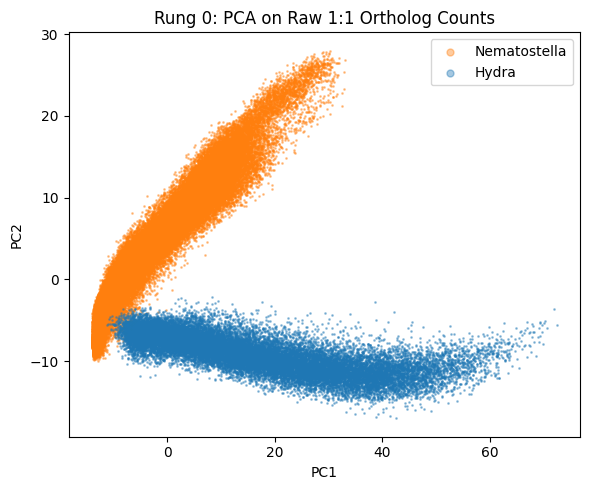

In [17]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

# 1. Extract raw count matrix and metadata
if "counts" in joint.layers:
    X_raw = joint.layers["counts"]
else:
    X_raw = joint.X

if hasattr(X_raw, "toarray"):
    X_raw = X_raw.toarray()
else:
    X_raw = np.array(X_raw)

species_labels = joint.obs["species"].values

# 2. Define mixing evaluation metric (k=30)
def evaluate_mixing(emb, species, k=30):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(emb)
    idx = nbrs.kneighbors(emb, return_distance=False)[:, 1:]
    mixing_score = (species[idx] != species[:, None]).mean()
    return mixing_score

# Baseline PCA (Rung 0)
pca_raw = PCA(n_components=20, random_state=0)
emb_raw = pca_raw.fit_transform(X_raw

mix_raw = evaluate_mixing(emb_raw[:, :2], species_labels)
print(f"Rung 0 (Raw Counts) Mixing Score: {mix_raw:.3f}")

# Plot Rung 0
fig, ax = plt.subplots(figsize=(6, 5))
for sp, color in zip(["Nematostella", "Hydra"], ["#ff7f0e", "#1f77b4"]):
    mask = species_labels == sp
    ax.scatter(emb_raw[mask, 0], emb_raw[mask, 1], s=1, alpha=0.4, label=sp, c=color)
ax.set_title("Rung 0: PCA on Raw 1:1 Ortholog Counts")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

0. raw counts                      mixing=0.00 (max 0.33)


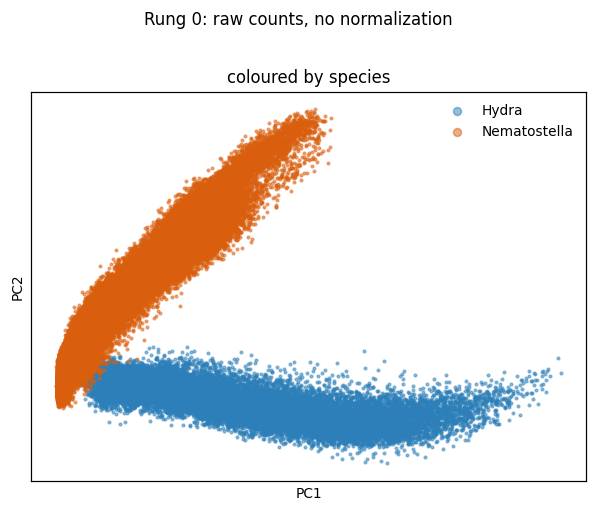

/tmp/ipykernel_3673954/4266275437.py:69: RuntimeWarning: invalid value encountered in log1p
  out = np.log1p(M / s * 1e4)


1. CP10K + log1p                   mixing=0.00 (max 0.33)


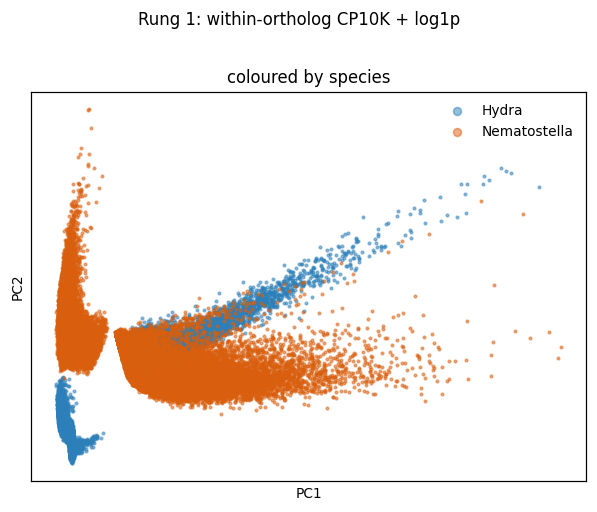

/tmp/ipykernel_3673954/4266275437.py:69: RuntimeWarning: invalid value encountered in log1p
  out = np.log1p(M / s * 1e4)


2. downsample + CP10K + log1p      mixing=0.00 (max 0.33)
3. z-scaled on cell mean           mixing=0.00 (max 0.33)


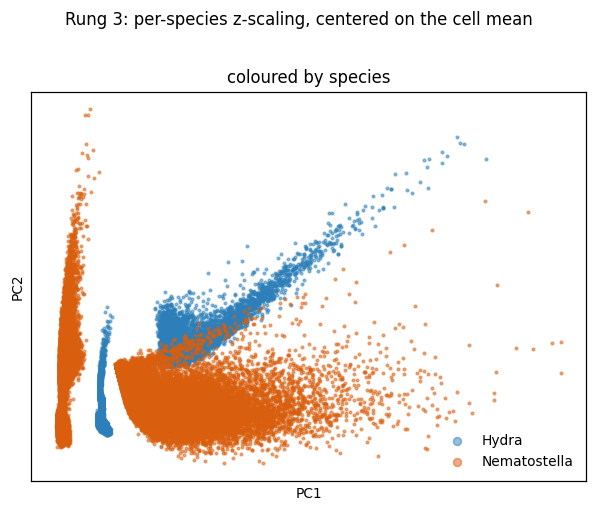

4. z-scaled on cluster centroids   mixing=0.00 (max 0.33)


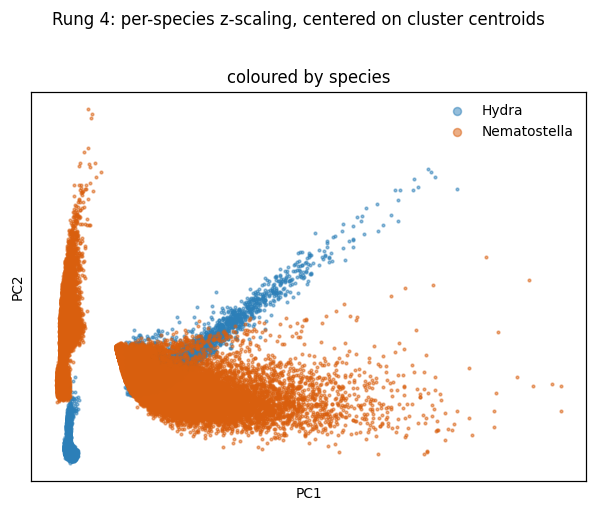

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# -------------------------------------------------------------------------
# 0. Extract matrices and clean NaNs / Infs
# -------------------------------------------------------------------------
X = joint.layers["counts"] if "counts" in joint.layers else joint.X
if hasattr(X, "toarray"):
    X = X.toarray().astype(float)
else:
    X = np.array(X, dtype=float)

# Replace all NaNs and infinite values with 0.0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

sp = np.array(joint.obs["species"].values)
SPECIES = np.unique(sp).tolist()

# -------------------------------------------------------------------------
# Evaluation helper functions
# -------------------------------------------------------------------------
RANDOM_MIX = 2 * (sp == SPECIES[0]).mean() * (sp == SPECIES[1]).mean()

def evaluate(emb, k=30):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(emb).kneighbors(emb, return_distance=False)[:, 1:]
    return (sp[idx] != sp[:, None]).mean()

results = {}
def report(name, emb):
    mix = evaluate(emb)
    results[name] = mix
    print(f"{name:34s} mixing={mix:.2f} (max {RANDOM_MIX:.2f})")
    return emb

def plot_pca(emb, title):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    colors = ["#2c7fb8", "#d95f0e"]
    for s, col in zip(SPECIES, colors):
        m = sp == s
        ax.scatter(emb[m, 0], emb[m, 1], s=3, alpha=0.5, c=col, label=s)
    ax.legend(markerscale=3, frameon=False)
    ax.set_title("coloured by species")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------------
# Rung 0: Raw counts (Baseline)
# -------------------------------------------------------------------------
emb0 = report("0. raw counts", PCA(20, random_state=0).fit_transform(X))
plot_pca(emb0, "Rung 0: raw counts, no normalization")

# -------------------------------------------------------------------------
# Rung 1: Ortholog-restricted CP10K + log1p
# -------------------------------------------------------------------------
def cp10k_log(M):
    s = M.sum(1, keepdims=True)
    s[s == 0] = 1.0
    out = np.log1p(M / s * 1e4)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

Y1 = cp10k_log(X)
emb1 = report("1. CP10K + log1p", PCA(20, random_state=0).fit_transform(Y1))
plot_pca(emb1, "Rung 1: within-ortholog CP10K + log1p")

# -------------------------------------------------------------------------
# Rung 2: Downsample to equalize depth
# -------------------------------------------------------------------------
def downsample_to(M, target):
    rng = np.random.default_rng(0)
    out = np.empty_like(M, dtype=float)
    target = int(target)
    
    for i, row in enumerate(M):
        tot = int(row.sum())
        if tot <= target or tot == 0:
            out[i] = row
        else:
            pvals = np.maximum(row, 0.0)
            pvals_sum = pvals.sum()
            if pvals_sum == 0:
                out[i] = row
            else:
                pvals = pvals / pvals_sum
                pvals[-1] = max(0.0, 1.0 - pvals[:-1].sum())
                out[i] = rng.multinomial(target, pvals).astype(float)
    return out

target_depth = int(np.median(X[sp == "Hydra"].sum(1)))
Xd = downsample_to(X, target_depth)
Y2 = cp10k_log(Xd)
emb2 = report("2. downsample + CP10K + log1p", PCA(20, random_state=0).fit_transform(Y2))

# -------------------------------------------------------------------------
# Rung 3: Per-species z-scaling centered on cell mean
# -------------------------------------------------------------------------
def zscale(Y, centers=None):
    Z = Y.copy()
    for s in SPECIES:
        m = sp == s
        mu = Y[m].mean(0) if centers is None else centers[s].mean(0)
        sd = Y[m].std(0)
        sd = np.where(sd < 1e-8, 1.0, sd)
        Z[m] = (Y[m] - mu) / sd
    return np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)

Y3 = zscale(Y2)
emb3 = report("3. z-scaled on cell mean", PCA(20, random_state=0).fit_transform(Y3))
plot_pca(emb3, "Rung 3: per-species z-scaling, centered on the cell mean")

# -------------------------------------------------------------------------
# Rung 4: Per-species z-scaling centered on cluster centroids
# -------------------------------------------------------------------------
centroids = {}
for s in SPECIES:
    m = sp == s
    pcs = PCA(20, random_state=0).fit_transform(Y2[m])
    lab = KMeans(n_clusters=10, n_init=10, random_state=0).fit_predict(pcs)
    centroids[s] = np.vstack([Y2[m][lab == k].mean(0) for k in range(10)])

Y4 = zscale(Y2, centers=centroids)
emb4 = report("4. z-scaled on cluster centroids", PCA(20, random_state=0).fit_transform(Y4))
plot_pca(emb4, "Rung 4: per-species z-scaling, centered on cluster centroids")

Rung 4 (Cleaned) Mixing Score: 0.24 (max 0.35)


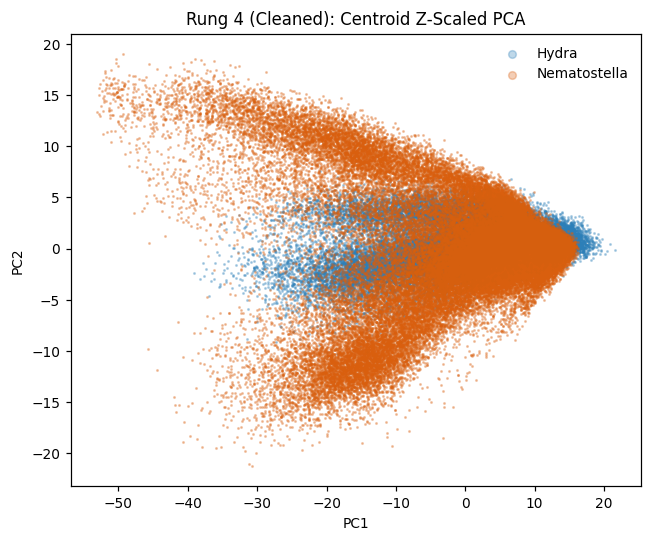

In [22]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# 1. Clean extraction of raw counts
X_raw = joint.layers["counts"] if "counts" in joint.layers else joint.X
if hasattr(X_raw, "toarray"):
    X_raw = X_raw.toarray().astype(np.float32)
else:
    X_raw = np.array(X_raw, dtype=np.float32)

# Ensure strictly non-negative values
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_raw = np.maximum(X_raw, 0.0)

# Filter out empty/near-empty cells (< 50 counts in orthologs)
cell_counts = X_raw.sum(axis=1)
valid_cells = cell_counts >= 50

X_filt = X_raw[valid_cells]
sp_filt = np.array(joint.obs["species"].values)[valid_cells]
SPECIES = np.unique(sp_filt).tolist()

# 2. Ortholog CP10K + log1p
library_sizes = X_filt.sum(axis=1, keepdims=True)
library_sizes[library_sizes == 0] = 1.0
Y_norm = np.log1p((X_filt / library_sizes) * 1e4)

# 3. Compute Centroids per biological cell type (or Leiden clusters)
# Using real cell type labels if available, otherwise 15 K-Means clusters per species
centroids = {}
for s in SPECIES:
    m = sp_filt == s
    # Sub-PCA on individual species to cluster on biological signal
    pca_sp = PCA(n_components=15, random_state=0)
    pcs = pca_sp.fit_transform(Y_norm[m])
    
    from sklearn.cluster import MiniBatchKMeans
    km = MiniBatchKMeans(n_clusters=15, batch_size=2048, random_state=0)
    labs = km.fit_predict(pcs)
    
    # Average cluster expression profiles
    c_matrix = np.vstack([Y_norm[m][labs == k].mean(axis=0) for k in range(15)])
    centroids[s] = c_matrix

# 4. Rung 4: Center on Cluster Centroid Mean and scale per-species SD
Z_scaled = Y_norm.copy()
for s in SPECIES:
    m = sp_filt == s
    centroid_mean = centroids[s].mean(axis=0)
    gene_sd = Y_norm[m].std(axis=0)
    gene_sd[gene_sd < 1e-6] = 1.0
    Z_scaled[m] = (Y_norm[m] - centroid_mean) / gene_sd

Z_scaled = np.nan_to_num(Z_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# 5. Final PCA
pca_final = PCA(n_components=20, random_state=0)
emb_final = pca_final.fit_transform(Z_scaled)

# Evaluate mixing
nbrs = NearestNeighbors(n_neighbors=31).fit(emb_final[:, :2])
idx = nbrs.kneighbors(emb_final[:, :2], return_distance=False)[:, 1:]
mix_score = (sp_filt[idx] != sp_filt[:, None]).mean()
random_max = 2 * (sp_filt == SPECIES[0]).mean() * (sp_filt == SPECIES[1]).mean()

print(f"Rung 4 (Cleaned) Mixing Score: {mix_score:.2f} (max {random_max:.2f})")

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#2c7fb8", "#d95f0e"]
for s, col in zip(SPECIES, colors):
    m = sp_filt == s
    ax.scatter(emb_final[m, 0], emb_final[m, 1], s=1, alpha=0.3, c=col, label=s)
ax.legend(markerscale=5, frameon=False)
ax.set_title("Rung 4 (Cleaned): Centroid Z-Scaled PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

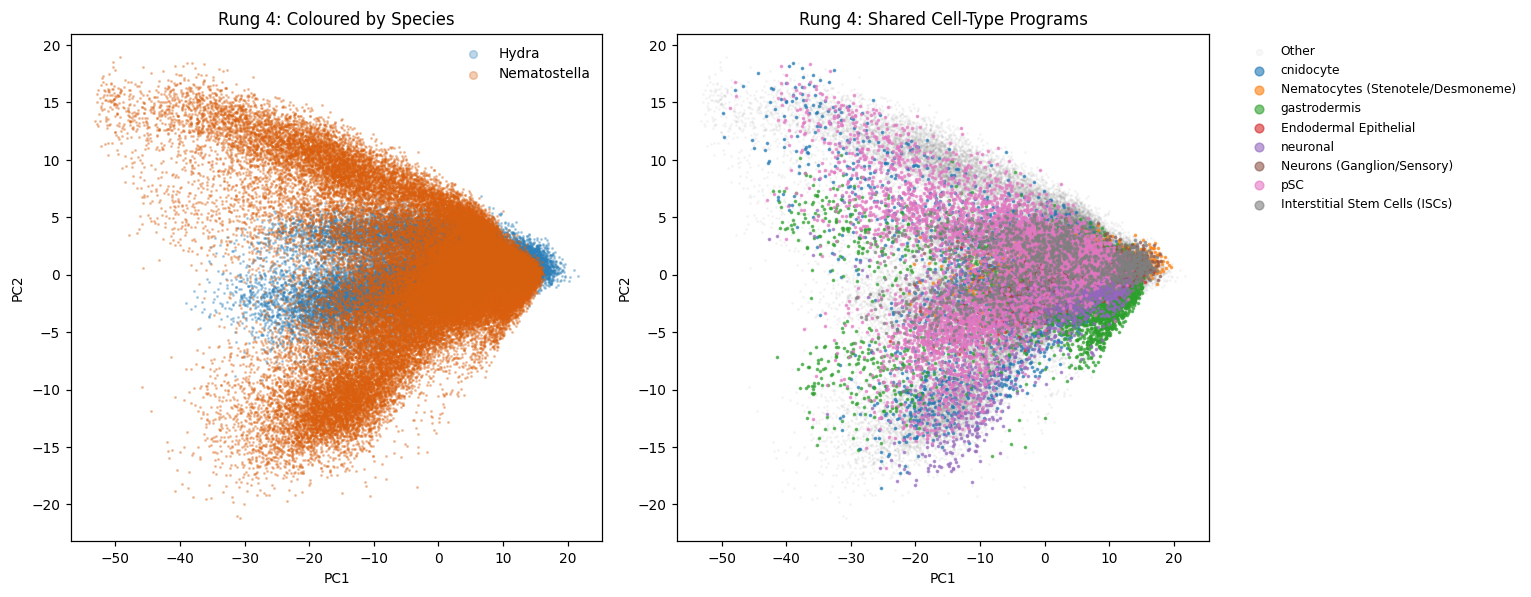

In [23]:
# Create metadata Series for plotting
cell_types = pd.Series(index=joint.obs.index, dtype=str)

# Map cell type columns from each atlas
if "Partition_ID" in joint.obs:
    mask_nv = joint.obs["species"] == "Nematostella"
    cell_types[mask_nv] = joint.obs.loc[mask_nv, "Partition_ID"].astype(str)

if "siebert_cell_type" in joint.obs:
    mask_hy = joint.obs["species"] == "Hydra"
    cell_types[mask_hy] = joint.obs.loc[mask_hy, "siebert_cell_type"].astype(str)

# Filter for the valid cells used in the PCA
cell_types_filt = cell_types.values[valid_cells]

# Side-by-side plot: Species mixing vs. Cell-type alignment
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Coloured by Species
for s, col in zip(SPECIES, ["#2c7fb8", "#d95f0e"]):
    m = sp_filt == s
    axes[0].scatter(emb_final[m, 0], emb_final[m, 1], s=1, alpha=0.3, c=col, label=s)
axes[0].legend(markerscale=5, frameon=False)
axes[0].set_title("Rung 4: Coloured by Species")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# 2. Highlight shared cell programs (e.g., Cnidocyte/Nematocyte, Stem, Gland, Neuronal)
# Plot background
axes[1].scatter(emb_final[:, 0], emb_final[:, 1], s=1, alpha=0.05, c="gray", label="Other")

# Highlight key matching pairs
highlight_types = [
    "cnidocyte", "Nematocytes (Stenotele/Desmoneme)",
    "gastrodermis", "Endodermal Epithelial",
    "neuronal", "Neurons (Ganglion/Sensory)",
    "pSC", "Interstitial Stem Cells (ISCs)"
]

for ct in highlight_types:
    m = cell_types_filt == ct
    if m.sum() > 0:
        axes[1].scatter(emb_final[m, 0], emb_final[m, 1], s=2, alpha=0.6, label=ct)

axes[1].legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=8)
axes[1].set_title("Rung 4: Shared Cell-Type Programs")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------------------------
# 1. Check if downsampling is necessary (median depth ratio)
# -------------------------------------------------------------------------
med_nv = np.median(X_filt[sp_filt == "Nematostella"].sum(axis=1))
med_hy = np.median(X_filt[sp_filt == "Hydra"].sum(axis=1))
print(f"Median Ortholog Depth -> Nematostella: {med_nv:.0f}, Hydra: {med_hy:.0f}")

# -------------------------------------------------------------------------
# 2. Extract Centroids using independent per-species Leiden clustering
# -------------------------------------------------------------------------
centroids = {}

for s in SPECIES:
    m = sp_filt == s
    # Build temporary AnnData for the individual species
    adata_sp = sc.AnnData(X=Y_norm[m].copy())
    sc.pp.pca(adata_sp, n_comps=20)
    sc.pp.neighbors(adata_sp, n_neighbors=30, n_pcs=15)
    sc.tl.leiden(adata_sp, resolution=0.8, key_added="leiden")
    
    # Calculate mean expression for each data-driven Leiden cluster
    c_list = []
    for k in adata_sp.obs["leiden"].unique():
        cluster_mask = adata_sp.obs["leiden"] == k
        c_list.append(Y_norm[m][cluster_mask.values].mean(axis=0))
        
    centroids[s] = np.vstack(c_list)
    print(f"{s}: Extracted {len(c_list)} Leiden cluster centroids")

# -------------------------------------------------------------------------
# 3. Apply Centroid Z-Scaling (Rung 4)
# -------------------------------------------------------------------------
Z_scaled = Y_norm.copy()
for s in SPECIES:
    m = sp_filt == s
    centroid_mean = centroids[s].mean(axis=0)
    gene_sd = Y_norm[m].std(axis=0)
    gene_sd[gene_sd < 1e-6] = 1.0
    Z_scaled[m] = (Y_norm[m] - centroid_mean) / gene_sd

Z_scaled = np.nan_to_num(Z_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# -------------------------------------------------------------------------
# 4. Final PCA & Mixing Evaluation
# -------------------------------------------------------------------------
pca_final = PCA(n_components=20, random_state=0)
emb_final = pca_final.fit_transform(Z_scaled)

nbrs = NearestNeighbors(n_neighbors=31).fit(emb_final[:, :2])
idx = nbrs.kneighbors(emb_final[:, :2], return_distance=False)[:, 1:]
mix_score = (sp_filt[idx] != sp_filt[:, None]).mean()
random_max = 2 * (sp_filt == SPECIES[0]).mean() * (sp_filt == SPECIES[1]).mean()

print(f"Rung 4 (Leiden Centroids) Mixing Score: {mix_score:.2f} (max {random_max:.2f})")

Median Ortholog Depth -> Nematostella: 336, Hydra: 915


/tmp/ipykernel_3673954/1143720847.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sp, resolution=0.8, key_added="leiden")


Hydra: Extracted 22 Leiden cluster centroids
Nematostella: Extracted 25 Leiden cluster centroids
Rung 4 (Leiden Centroids) Mixing Score: 0.22 (max 0.35)


Target downsampling depth (Nematostella median): 336
Post-Downsample Ortholog Depth -> Nematostella: 336, Hydra: 336
Rung 4 (Downsampled + Leiden Centroids) Mixing Score: 0.14 (max 0.35)


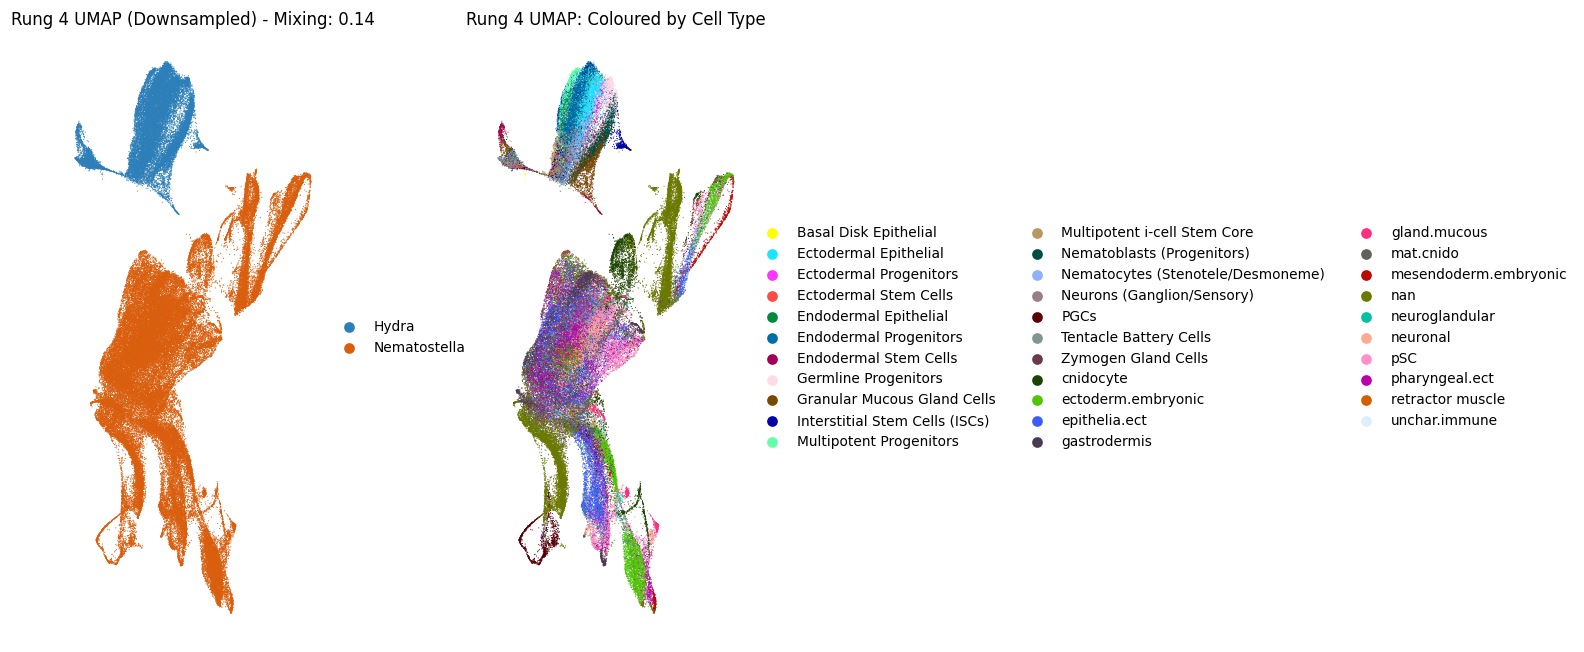

In [30]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# 1. Extract raw counts and clean NaNs/Infs
X_raw = joint.layers["counts"] if "counts" in joint.layers else joint.X
if hasattr(X_raw, "toarray"):
    X_raw = X_raw.toarray().astype(np.float32)
else:
    X_raw = np.array(X_raw, dtype=np.float32)

X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_raw = np.maximum(X_raw, 0.0)

cell_counts = X_raw.sum(axis=1)
valid_cells = cell_counts >= 50

X_filt = X_raw[valid_cells]
sp_filt = np.array(joint.obs["species"].values)[valid_cells]
SPECIES = np.unique(sp_filt).tolist()
def downsample_to(M, target, species_arr):
    rng = np.random.default_rng(0)
    out = np.empty_like(M, dtype=float)
    target = int(target)
    
    for i, (row, sp_val) in enumerate(zip(M, species_arr)):
        tot = int(row.sum())
        if sp_val == "Hydra" and tot > target:
            # Explicitly cast to float64 to prevent NumPy internal casting errors
            pvals = np.maximum(row, 0.0).astype(np.float64)
            pvals_sum = pvals.sum()
            
            if pvals_sum == 0:
                out[i] = row
            else:
                pvals = pvals / pvals_sum
                # Force strictly valid bounds for multinomial pvals
                pvals = np.clip(pvals, 0.0, 1.0)
                pvals[-1] = max(0.0, 1.0 - pvals[:-1].sum())
                
                out[i] = rng.multinomial(target, pvals).astype(float)
        else:
            out[i] = row
    return out

target_depth = int(np.median(X_filt[sp_filt == "Nematostella"].sum(axis=1)))
print(f"Target downsampling depth (Nematostella median): {target_depth}")
Xd = downsample_to(X_filt, target_depth, sp_filt)

# Check new median depths after downsampling
med_nv_d = np.median(Xd[sp_filt == "Nematostella"].sum(axis=1))
med_hy_d = np.median(Xd[sp_filt == "Hydra"].sum(axis=1))
print(f"Post-Downsample Ortholog Depth -> Nematostella: {med_nv_d:.0f}, Hydra: {med_hy_d:.0f}")

# 3. Ortholog-Restricted CP10K + log1p
library_sizes = Xd.sum(axis=1, keepdims=True)
library_sizes[library_sizes == 0] = 1.0
Y_norm = np.log1p((Xd / library_sizes) * 1e4)

# 4. Independent Per-Species Leiden Clustering & Centroid Extraction
centroids = {}
for s in SPECIES:
    m = sp_filt == s
    adata_sp = sc.AnnData(X=Y_norm[m].copy())
    sc.pp.pca(adata_sp, n_comps=20)
    sc.pp.neighbors(adata_sp, n_neighbors=30, n_pcs=15)
    sc.tl.leiden(adata_sp, resolution=0.8, key_added="leiden")
    
    c_list = []
    for k in adata_sp.obs["leiden"].unique():
        cluster_mask = adata_sp.obs["leiden"] == k
        c_list.append(Y_norm[m][cluster_mask.values].mean(axis=0))
    centroids[s] = np.vstack(c_list)

# 5. Rung 4: Cluster-Centroid Z-Scaling
Z_scaled = Y_norm.copy()
for s in SPECIES:
    m = sp_filt == s
    centroid_mean = centroids[s].mean(axis=0)
    gene_sd = Y_norm[m].std(axis=0)
    gene_sd[gene_sd < 1e-6] = 1.0
    Z_scaled[m] = (Y_norm[m] - centroid_mean) / gene_sd

Z_scaled = np.nan_to_num(Z_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# 6. Final PCA & Mixing Evaluation
pca_final = PCA(n_components=20, random_state=0)
emb_final = pca_final.fit_transform(Z_scaled)

nbrs = NearestNeighbors(n_neighbors=31).fit(emb_final[:, :2])
idx = nbrs.kneighbors(emb_final[:, :2], return_distance=False)[:, 1:]
mix_score = (sp_filt[idx] != sp_filt[:, None]).mean()
random_max = 2 * (sp_filt == SPECIES[0]).mean() * (sp_filt == SPECIES[1]).mean()

print(f"Rung 4 (Downsampled + Leiden Centroids) Mixing Score: {mix_score:.2f} (max {random_max:.2f})")

# 7. Build AnnData and Plot UMAP
cell_types = pd.Series(index=joint.obs.index, dtype=str)
if "Partition_ID" in joint.obs:
    mask_nv = joint.obs["species"] == "Nematostella"
    cell_types[mask_nv] = joint.obs.loc[mask_nv, "Partition_ID"].astype(str)
if "siebert_cell_type" in joint.obs:
    mask_hy = joint.obs["species"] == "Hydra"
    cell_types[mask_hy] = joint.obs.loc[mask_hy, "siebert_cell_type"].astype(str)

cell_types_filt = cell_types.values[valid_cells]

adata_r4 = sc.AnnData(
    obs=pd.DataFrame({
        "species": sp_filt,
        "cell_type": cell_types_filt
    }, index=joint.obs_names[valid_cells])
)
adata_r4.obsm["X_pca"] = emb_final[:, :15]

sc.pp.neighbors(adata_r4, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(adata_r4, min_dist=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.umap(adata_r4, color="species", ax=axes[0], show=False, size=2, frameon=False, palette=["#2c7fb8", "#d95f0e"])
axes[0].set_title(f"Rung 4 UMAP (Downsampled) - Mixing: {mix_score:.2f}")

sc.pl.umap(adata_r4, color="cell_type", ax=axes[1], show=False, size=2, frameon=False, legend_loc="right margin")
axes[1].set_title("Rung 4 UMAP: Coloured by Cell Type")

plt.tight_layout()
plt.show()

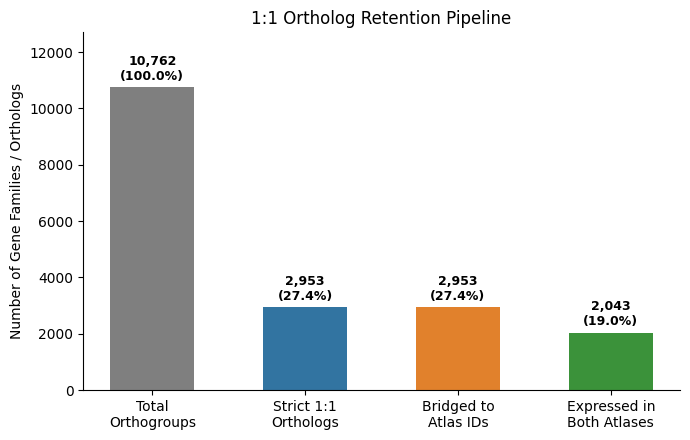

In [21]:
import matplotlib.pyplot as plt

# Data from your filtering steps
stages = [
    "Total\nOrthogroups",
    "Strict 1:1\nOrthologs",
    "Bridged to\nAtlas IDs",
    "Expressed in\nBoth Atlases"
]
counts = [
    len(orthogroups),       # 10,762
    len(one_to_one),        # 4,815
    len(one_to_one_nve),    # 2,953
    joint.shape[1]          # 2,043
]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(stages, counts, color=['#7f7f7f', '#3274a1', '#e1812c', '#3b923a'], width=0.55)

# Add counts and percentages on top of bars
for bar in bars:
    height = bar.get_height()
    pct = (height / counts[0]) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 150,
            f"{int(height):,}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("Number of Gene Families / Orthologs")
ax.set_title("1:1 Ortholog Retention Pipeline")
ax.set_ylim(0, counts[0] * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

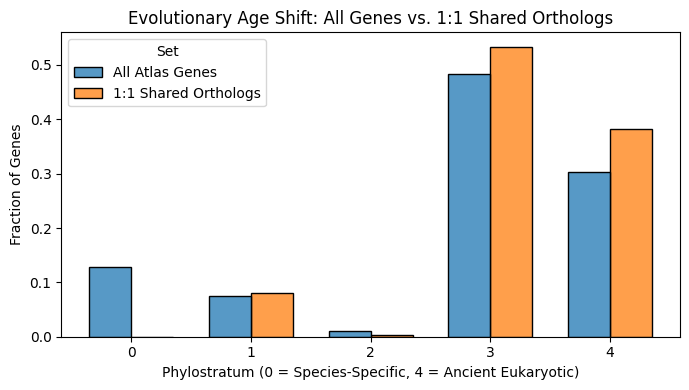

In [22]:
import pandas as pd
import seaborn as sns

# Extract age for whole genome vs 1:1 orthologs
all_nv_ages = pd.Series(nv_age_by_nve, name="Age")
one_to_one_ages = one_to_one_nve["nv_atlas_gene_nve"].map(nv_age_by_nve).dropna().rename("Age")

plot_df = pd.concat([
    pd.DataFrame({"Age": all_nv_ages, "Set": "All Atlas Genes"}),
    pd.DataFrame({"Age": one_to_one_ages, "Set": "1:1 Shared Orthologs"})
])

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=plot_df, x="Age", hue="Set", 
    stat="density", common_norm=False, 
    discrete=True, multiple="dodge", shrink=0.7, ax=ax
)
ax.set_title("Evolutionary Age Shift: All Genes vs. 1:1 Shared Orthologs")
ax.set_xlabel("Phylostratum (0 = Species-Specific, 4 = Ancient Eukaryotic)")
ax.set_ylabel("Fraction of Genes")
ax.set_xticks([0, 1, 2, 3, 4])

plt.tight_layout()
plt.show()

In [23]:
# Check how specific the 1:1 shared genes are across Nematostella cell types
top_markers_nvec = nv_pb_shared.idxmax(axis=1).value_counts()
print("Distribution of 1:1 shared genes acting as top cell-type markers:")
print(top_markers_nvec)

Distribution of 1:1 shared genes acting as top cell-type markers:
ectoderm.embryonic       1628
epithelia.ect             140
pSC                        78
cnidocyte                  58
gastrodermis               54
PGCs                       23
neuronal                   14
gland.mucous               13
pharyngeal.ect             10
neuroglandular              9
mat.cnido                   9
mesendoderm.embryonic       7
Name: count, dtype: int64


In [26]:
# 1. Normalize each cell type by its total pseudobulk library size (CPM)
nv_pb_cpm = nv_pb_shared / nv_pb_shared.sum(axis=0) * 1e6

# 2. Check the distribution across cell types on normalized expression
top_markers_norm = nv_pb_cpm.idxmax(axis=1).value_counts()
print("=== Normalized Top Cell-Type Markers (CPM-based) ===")
print(top_markers_norm)

=== Normalized Top Cell-Type Markers (CPM-based) ===
mat.cnido                519
PGCs                     460
mesendoderm.embryonic    389
ectoderm.embryonic       115
neuronal                  94
cnidocyte                 87
gland.mucous              85
unchar.immune             83
retractor muscle          61
gastrodermis              50
pSC                       48
neuroglandular            28
epithelia.ect             13
pharyngeal.ect            11
Name: count, dtype: int64


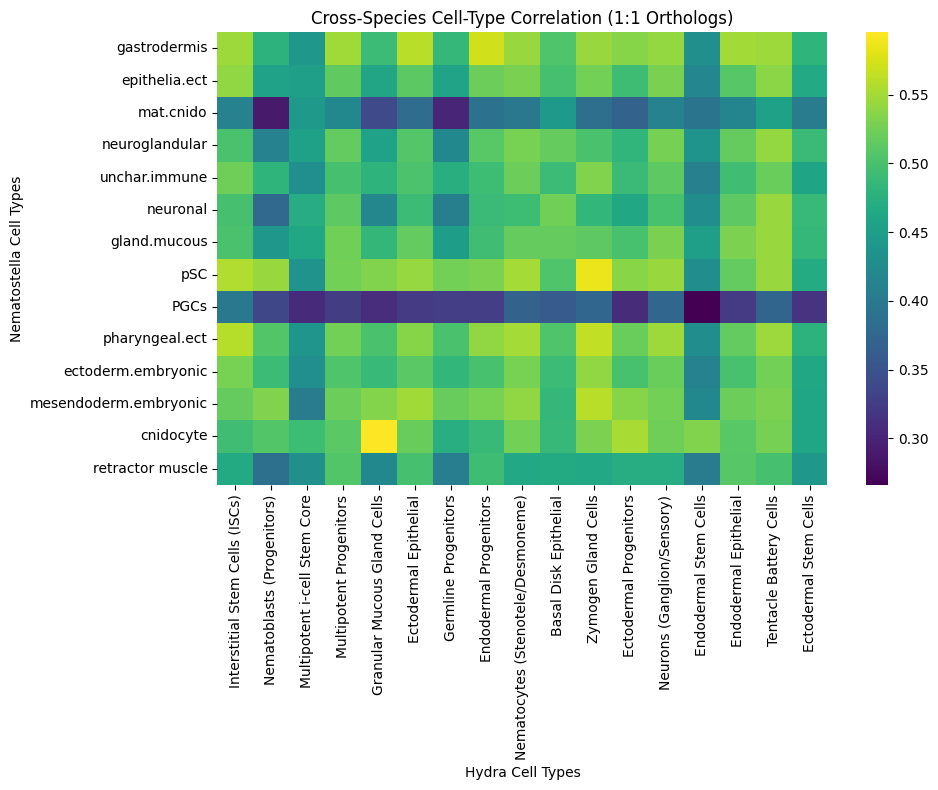

In [27]:
# 1. Normalize Hydra pseudobulk to CPM as well
hy_pb_cpm = hy_pb_shared / hy_pb_shared.sum(axis=0) * 1e6

# 2. Compute Spearman correlation between all cell types
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

cell_corr = pd.DataFrame(
    index=nv_pb_cpm.columns, 
    columns=hy_pb_cpm.columns,
    data=[[stats.spearmanr(nv_pb_cpm[c1], hy_pb_cpm[c2])[0] 
           for c2 in hy_pb_cpm.columns] 
          for c1 in nv_pb_cpm.columns]
)

# 3. Plot Cross-Species Cell-Type Homology Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cell_corr, cmap="viridis", annot=False)
plt.title("Cross-Species Cell-Type Correlation (1:1 Orthologs)")
plt.xlabel("Hydra Cell Types")
plt.ylabel("Nematostella Cell Types")
plt.tight_layout()
plt.show()

In [29]:
# 1. Find the top-correlating Hydra cell type for each Nematostella cell type
best_matches = []
for nv_ct in cell_corr.index:
    top_hy_ct = cell_corr.loc[nv_ct].idxmax()
    max_corr = cell_corr.loc[nv_ct].max()
    best_matches.append({
        "nvec_cell_type": nv_ct,
        "hydra_best_match": top_hy_ct,
        "correlation": max_corr
    })

matched_pairs_df = pd.DataFrame(best_matches).sort_values("correlation", ascending=False)
print("=== Homologous Cell-Type Pairs (Ranked by Correlation) ===")
print(matched_pairs_df.to_string(index=False))

=== Homologous Cell-Type Pairs (Ranked by Correlation) ===
       nvec_cell_type               hydra_best_match  correlation
            cnidocyte    Granular Mucous Gland Cells     0.595419
                  pSC            Zymogen Gland Cells     0.585825
         gastrodermis         Endodermal Progenitors     0.571388
       pharyngeal.ect            Zymogen Gland Cells     0.563980
mesendoderm.embryonic            Zymogen Gland Cells     0.560325
         gland.mucous         Tentacle Battery Cells     0.544348
             neuronal         Tentacle Battery Cells     0.544312
       neuroglandular         Tentacle Battery Cells     0.541973
        epithelia.ect Interstitial Stem Cells (ISCs)     0.540647
   ectoderm.embryonic            Zymogen Gland Cells     0.540279
        unchar.immune            Zymogen Gland Cells     0.533229
     retractor muscle          Endodermal Epithelial     0.508767
            mat.cnido         Tentacle Battery Cells     0.454194
                 

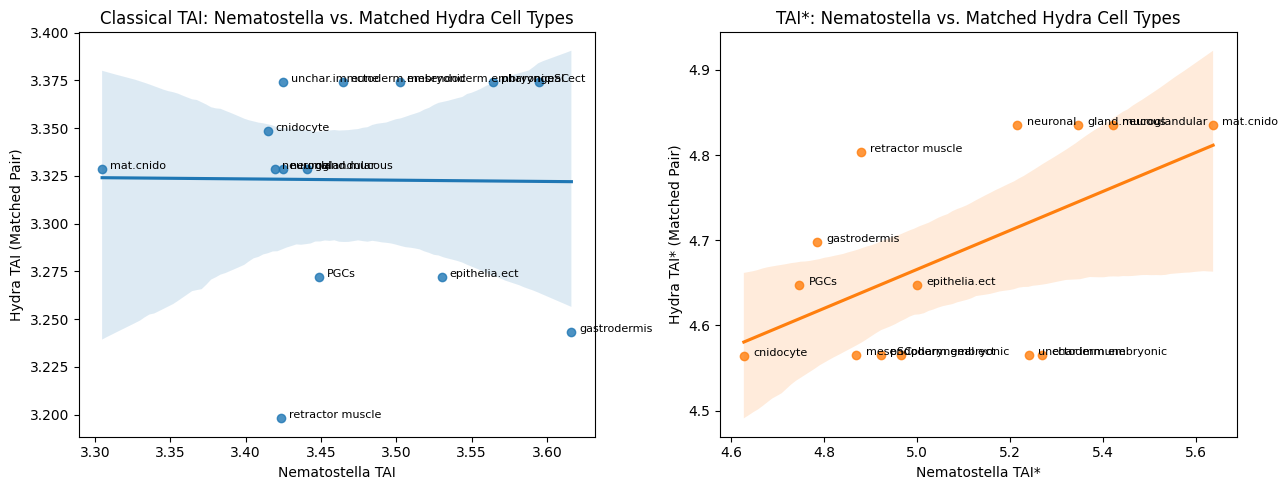

In [30]:
# Merge the TAI / TAI* scores from your earlier steps onto the matched pairs
tai_comp = matched_pairs_df.merge(
    nv_classical[["cell_type", "age_score"]].rename(columns={"cell_type": "nvec_cell_type", "age_score": "nv_classical_tai"}),
    on="nvec_cell_type"
).merge(
    hy_classical[["cell_type", "age_score"]].rename(columns={"cell_type": "hydra_best_match", "age_score": "hy_classical_tai"}),
    on="hydra_best_match"
).merge(
    nv_star[["cell_type", "age_score"]].rename(columns={"cell_type": "nvec_cell_type", "age_score": "nv_star_tai"}),
    on="nvec_cell_type"
).merge(
    hy_star[["cell_type", "age_score"]].rename(columns={"cell_type": "hydra_best_match", "age_score": "hy_star_tai"}),
    on="hydra_best_match"
)

# Plot: Cross-Species TAI and TAI* Concordance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot A: Classical TAI
sns.regplot(data=tai_comp, x="nv_classical_tai", y="hy_classical_tai", ax=axes[0], color="#1f77b4")
axes[0].set_title("Classical TAI: Nematostella vs. Matched Hydra Cell Types")
axes[0].set_xlabel("Nematostella TAI")
axes[0].set_ylabel("Hydra TAI (Matched Pair)")

# Label points
for _, row in tai_comp.iterrows():
    axes[0].text(row["nv_classical_tai"] + 0.005, row["hy_classical_tai"], row["nvec_cell_type"], fontsize=8)

# Plot B: TAI* (Paralog-Weighted)
sns.regplot(data=tai_comp, x="nv_star_tai", y="hy_star_tai", ax=axes[1], color="#ff7f0e")
axes[1].set_title("TAI*: Nematostella vs. Matched Hydra Cell Types")
axes[1].set_xlabel("Nematostella TAI*")
axes[1].set_ylabel("Hydra TAI* (Matched Pair)")

for _, row in tai_comp.iterrows():
    axes[1].text(row["nv_star_tai"] + 0.02, row["hy_star_tai"], row["nvec_cell_type"], fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
# 1. Start with the shared 1:1 ortholog table
master_df = one_to_one_nve.copy()

# 2. Map Phylostratum Ages and Paralog Counts
master_df["phylostratum_age"] = master_df["nv_atlas_gene_nve"].map(nv_age_by_nve)
master_df["n_paralogs_nvec"] = master_df["nv_atlas_gene_nve"].map(nv_copies_by_nve)
master_df["n_paralogs_hydra"] = master_df["hy_atlas_gene"].map(hy_copies_by_augustus)

# 3. Map Top Expressing Cell Type (using normalized CPM)
master_df["nvec_top_cell_type"] = master_df["Orthogroup"].map(nv_pb_cpm.idxmax(axis=1).to_dict())
master_df["hydra_top_cell_type"] = master_df["Orthogroup"].map(hy_pb_cpm.idxmax(axis=1).to_dict())

# 4. Check if top expressing cell type matches across species
master_df["cell_type_conserved"] = master_df["nvec_top_cell_type"] == master_df["hydra_top_cell_type"].map(
    matched_pairs_df.set_index("hydra_best_match")["nvec_cell_type"].to_dict()
)

print(f"Master Multi-Omics DataFrame created: {master_df.shape[0]} genes")
print(master_df[["Orthogroup", "nv_atlas_gene_nve", "hy_atlas_gene", "phylostratum_age", "nvec_top_cell_type", "cell_type_conserved"]].head(10))

Master Multi-Omics DataFrame created: 2953 genes
    Orthogroup nv_atlas_gene_nve hy_atlas_gene  phylostratum_age  \
217  OG0000217           NVE7626         g4265                 4   
512  OG0000512           NVE4561         g9857                 4   
697  OG0000697          NVE21618        g20769                 3   
729  OG0000729          NVE13938        g33503                 4   
739  OG0000739          NVE16429        g23100                 4   
820  OG0000820          NVE15590        g31345                 4   
821  OG0000821          NVE19100        g30489                 3   
876  OG0000876          NVE14101         g7641                 3   
881  OG0000881          NVE24749        g18743                 3   
885  OG0000885             NVE25        g25146                 4   

    nvec_top_cell_type  cell_type_conserved  
217                NaN                False  
512          mat.cnido                False  
697                NaN                False  
729               

In [33]:
# 1. Build dictionary mapping Hydra cell types to their homologous Nematostella counterparts
hy_to_nv_matched = matched_pairs_df.set_index("hydra_best_match")["nvec_cell_type"].to_dict()

# 2. Build the master table directly on the 2,043 expressed shared orthologs
master_clean = one_to_one_nve[one_to_one_nve["Orthogroup"].isin(nv_pb_cpm.index)].copy()

# Add metadata and ages
master_clean["phylostratum_age"] = master_clean["nv_atlas_gene_nve"].map(nv_age_by_nve)
master_clean["n_paralogs_nvec"] = master_clean["nv_atlas_gene_nve"].map(nv_copies_by_nve)
master_clean["n_paralogs_hydra"] = master_clean["hy_atlas_gene"].map(hy_copies_by_augustus)

# Add top cell types (from normalized CPM)
master_clean["nvec_top_cell_type"] = master_clean["Orthogroup"].map(nv_pb_cpm.idxmax(axis=1).to_dict())
master_clean["hydra_top_cell_type"] = master_clean["Orthogroup"].map(hy_pb_cpm.idxmax(axis=1).to_dict())

# Convert Hydra top cell type to its matched Nematostella equivalent
master_clean["hydra_matched_nv_type"] = master_clean["hydra_top_cell_type"].map(hy_to_nv_matched)

# Check conservation (True if both species peak in homologous cell types)
master_clean["cell_type_conserved"] = master_clean["nvec_top_cell_type"] == master_clean["hydra_matched_nv_type"]

# Summary statistics
n_conserved = master_clean["cell_type_conserved"].sum()
total_expressed = len(master_clean)

print(f"=== Cleaned Master Multi-Omics Table ===")
print(f"Total Expressed 1:1 Orthologs: {total_expressed}")
print(f"Genes with Conserved Cell-Type Specificity: {n_conserved} / {total_expressed} ({n_conserved/total_expressed*100:.1f}%)\n")

# Preview top conserved genes
print("=== Top Conserved Ortholog Examples ===")
print(master_clean[master_clean["cell_type_conserved"]][
    ["Orthogroup", "nv_atlas_gene_nve", "hy_atlas_gene", "phylostratum_age", "nvec_top_cell_type", "hydra_top_cell_type"]
].head(10).to_string(index=False))

=== Cleaned Master Multi-Omics Table ===
Total Expressed 1:1 Orthologs: 2043
Genes with Conserved Cell-Type Specificity: 89 / 2043 (4.4%)

=== Top Conserved Ortholog Examples ===
Orthogroup nv_atlas_gene_nve hy_atlas_gene  phylostratum_age nvec_top_cell_type         hydra_top_cell_type
 OG0001627          NVE10964        g19503                 4          mat.cnido      Tentacle Battery Cells
 OG0001658          NVE22273        g14145                 3   retractor muscle       Endodermal Epithelial
 OG0001864          NVE14488        g31014                 3          mat.cnido      Tentacle Battery Cells
 OG0002103           NVE3098        g29723                 4       gastrodermis      Endodermal Progenitors
 OG0002152           NVE9839        g21396                 4          mat.cnido      Tentacle Battery Cells
 OG0002344          NVE16303         g1924                 3          cnidocyte Granular Mucous Gland Cells
 OG0002572            NVE106        g31933                 4     

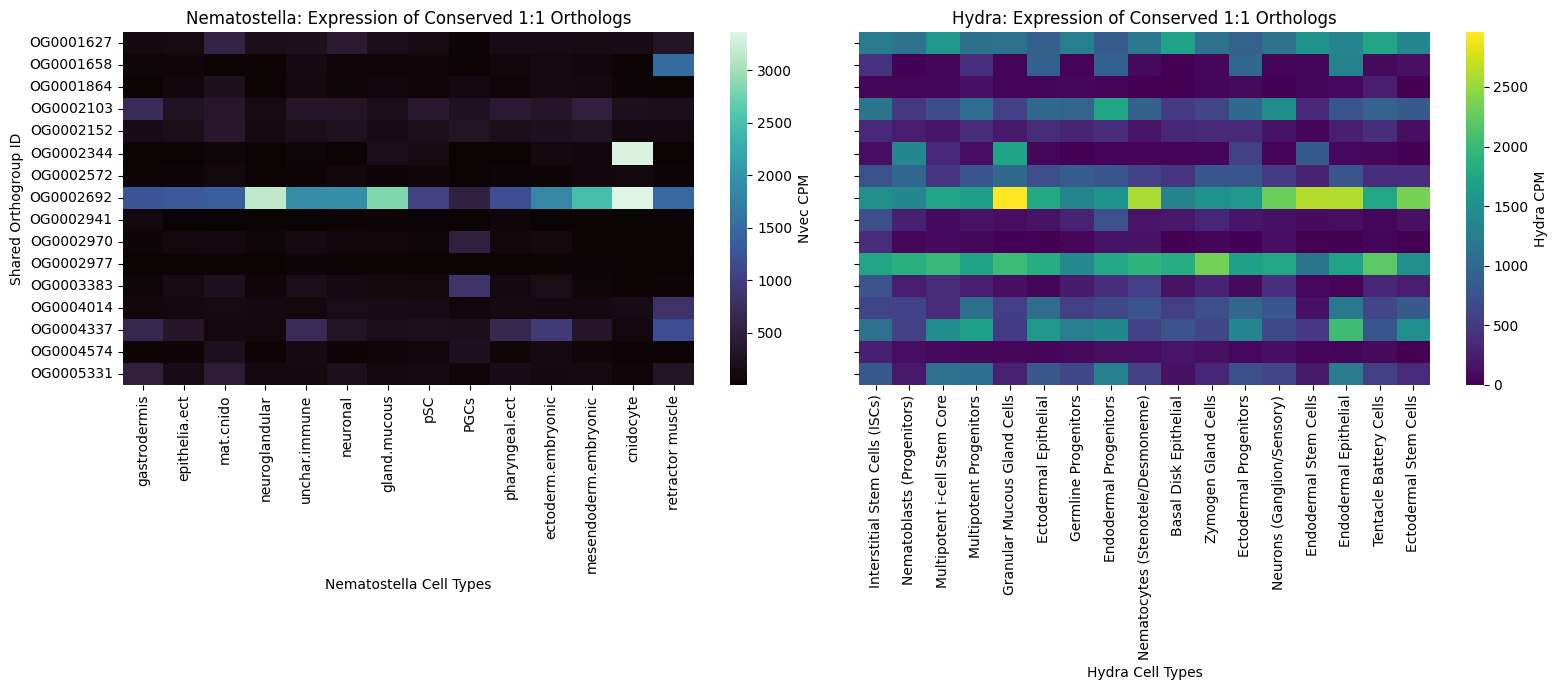

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the top conserved orthologs for plotting
conserved_subset = master_clean[master_clean["cell_type_conserved"]].groupby("nvec_top_cell_type").head(3)
selected_ogs = conserved_subset["Orthogroup"].tolist()

# 2. Extract normalized expression matrices for selected orthogroups
nv_plot_matrix = nv_pb_cpm.loc[selected_ogs]
hy_plot_matrix = hy_pb_cpm.loc[selected_ogs]

# 3. Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Nematostella Heatmap
sns.heatmap(
    nv_plot_matrix, 
    cmap="mako", 
    ax=axes[0], 
    cbar_kws={'label': 'Nvec CPM'}
)
axes[0].set_title("Nematostella: Expression of Conserved 1:1 Orthologs")
axes[0].set_xlabel("Nematostella Cell Types")
axes[0].set_ylabel("Shared Orthogroup ID")
axes[0].tick_params(axis='x', rotation=90)

# Hydra Heatmap
sns.heatmap(
    hy_plot_matrix, 
    cmap="viridis", 
    ax=axes[1], 
    cbar_kws={'label': 'Hydra CPM'}
)
axes[1].set_title("Hydra: Expression of Conserved 1:1 Orthologs")
axes[1].set_xlabel("Hydra Cell Types")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [34]:
# Breakdown of conserved genes per cell type
conserved_breakdown = master_clean[master_clean["cell_type_conserved"]]["nvec_top_cell_type"].value_counts()
print("\n=== Conserved 1:1 Marker Genes by Cell Type ===")
print(conserved_breakdown)


=== Conserved 1:1 Marker Genes by Cell Type ===
nvec_top_cell_type
PGCs                47
mat.cnido           16
cnidocyte           11
retractor muscle     8
gastrodermis         6
unchar.immune        1
Name: count, dtype: int64


In [24]:
#Compute PCA
sc.tl.pca(joint, svd_solver="arpack")
print("PCA complete. obsm keys:", list(joint.obsm.keys()))

PCA complete. obsm keys: ['X_pca']


In [20]:
sc.pp.scrublet(adata_nv, batch_key='sample')

print(adata_nv.obs['predicted_doublet'].value_counts())

/opt/conda/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


predicted_doublet
False    95006
True        36
Name: count, dtype: int64


In [28]:
# Cells with Siebert labels belong to Hydra, missing/unassigned belong to the second organism
joint.obs['organism'] = joint.obs['siebert_cell_type'].apply(
    lambda x: 'Hydra' if pd.notna(x) and x != 'Unknown' else 'Organism_2'
)
print(joint.obs['organism'].value_counts())


organism
Hydra    24458
Name: count, dtype: int64


2026-08-18 11:20:33,315 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-08-18 11:20:33,315 - harmonypy - INFO -   Parameters:
2026-08-18 11:20:33,315 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-18 11:20:33,315 - harmonypy - INFO -     max_iter_kmeans: 20
2026-08-18 11:20:33,316 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-08-18 11:20:33,316 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-08-18 11:20:33,316 - harmonypy - INFO -     nclust: 100
2026-08-18 11:20:33,316 - harmonypy - INFO -     block_size: 0.05
2026-08-18 11:20:33,316 - harmonypy - INFO -     lamb: [1. 1.]
2026-08-18 11:20:33,317 - harmonypy - INFO -     theta: [2. 2.]
2026-08-18 11:20:33,317 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-18 11:20:33,317 - harmonypy - INFO -     verbose: True
2026-08-18 11:20:33,317 - harmonypy - INFO -     random_state: 0
2026-08-18 11:20:33,317 - harmonypy - INFO -   Data: 50 PCs × 119500 cells
2026-08-18 11:20:33,317 - harmonypy - IN

Z_corr shape: (119500, 50)
n_obs: 119500


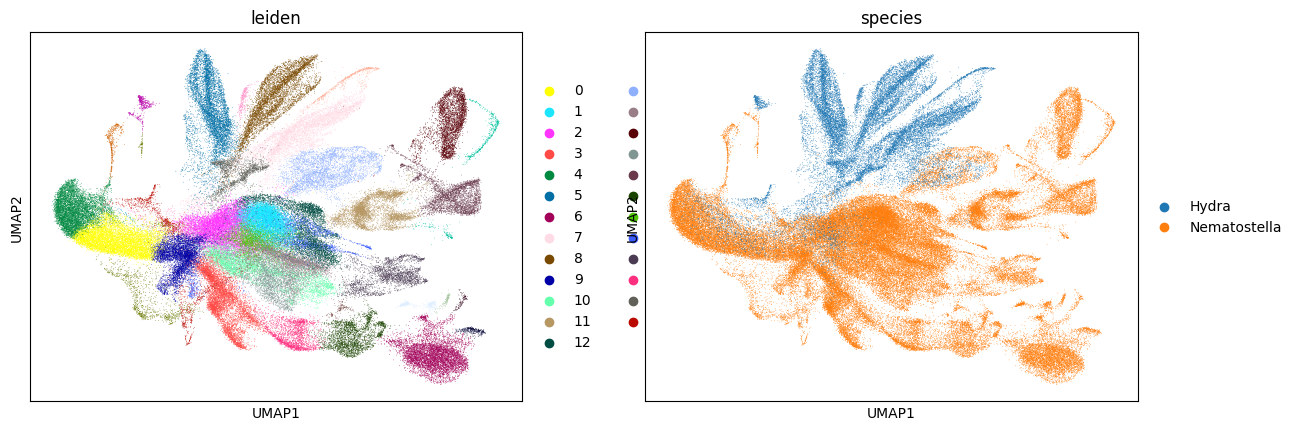

In [37]:
import numpy as np
import harmonypy

X = joint.obsm["X_pca"].astype(np.float64)
ho = harmonypy.run_harmony(X, joint.obs, "species")

print("Z_corr shape:", ho.Z_corr.shape)
print("n_obs:", joint.n_obs)

# Use whichever axis actually matches n_obs — do NOT reshape blindly
if ho.Z_corr.shape[0] == joint.n_obs:
    joint.obsm["X_pca_harmony"] = ho.Z_corr
elif ho.Z_corr.shape[1] == joint.n_obs:
    joint.obsm["X_pca_harmony"] = ho.Z_corr.T
else:
    raise ValueError(f"Unexpected shape {ho.Z_corr.shape}, doesn't match n_obs={joint.n_obs} on either axis")

sc.pp.neighbors(joint, use_rep="X_pca_harmony")
sc.tl.umap(joint)
sc.tl.leiden(joint)
sc.pl.umap(joint, color=["leiden", "species"])

In [38]:
# 1. Map TAI* score per cell based on cell_type annotation
adata_joint.obs["TAI_star"] = adata_joint.obs["cell_type"].map(
    nv_star.set_index("cell_type")["tai_score"]
).fillna(
    adata_joint.obs["cell_type"].map(hy_star.set_index("cell_type")["tai_score"])
)

# 2. Visualize Evolutionary Age & Paralog Load across the manifold
sc.pl.umap(
    adata_joint, 
    color=["species", "leiden", "TAI_star"], 
    cmap="magma", 
    wspace=0.3
)

NameError: name 'adata_joint' is not defined

In [37]:
adata_nv_clean = adata_nv[~adata_nv.obs['predicted_doublet']].copy()

print(f"Nematostella: {adata_nv.n_obs} -> {adata_nv_clean.n_obs} after doublet removal")


Nematostella: 95042 -> 95006 after doublet removal


## 9. How well did the two species actually mix?

For each new joint cluster, what fraction of its cells came from each species?
Clusters with a healthy mix of both (not close to 100% one species) are the
ones showing real, shared cross-species biology.


In [38]:
species_mix = pd.crosstab(joint.obs["leiden"], joint.obs["species"], normalize="index")
print(species_mix)

well_mixed = species_mix[(species_mix["Hydra"] > 0.3) & (species_mix["Nematostella"] > 0.3)]
print(f"\nWell-mixed clusters: {len(well_mixed)} out of {len(species_mix)}")


species     Hydra  Nematostella
leiden                         
0        0.000000      1.000000
1        0.017654      0.982346
2        0.320568      0.679432
3        0.000000      1.000000
4        0.000000      1.000000
5        0.994205      0.005795
6        0.000000      1.000000
7        0.000000      1.000000
8        0.000000      1.000000
9        0.504453      0.495547
10       0.000000      1.000000
11       0.995101      0.004899
12       0.991290      0.008710
13       0.000000      1.000000
14       0.000000      1.000000
15       0.000000      1.000000
16       0.000000      1.000000
17       1.000000      0.000000
18       0.000000      1.000000
19       0.000000      1.000000
20       0.000000      1.000000
21       0.000000      1.000000
22       0.000000      1.000000
23       0.000000      1.000000
24       0.000000      1.000000
25       0.000000      1.000000

Well-mixed clusters: 2 out of 26


## 10. Wrap-up

At this point you have:
- Classical TAI and TAI* for both species, individually
- A single-gene-dominance check for every result
- A joint, cross-species clustering built only from unambiguous 1:1 orthologs

Next natural steps (not run here): cross-reference specific matched cell types
against the joint clustering, and bring in independent validation (e.g. an
existing published age-index tool) to confirm the pattern holds up outside
this pipeline.


## 11. What kinds of genes are in our 1:1 ortholog set?

Before looking at individual cell types, let's characterize the whole 1:1
ortholog list functionally, using GO (Gene Ontology) enrichment. This tells us
what kind of biology this "clean, unambiguous" gene set is actually made of —
useful context before we narrow down further.

We need a human gene name for each ortholog to query GO databases. Hydra's
gene IDs already have a human ortholog name built in
(e.g. `g10012.t1|ZSWM1_HUMAN`), so we use that.


In [39]:
import re

def extract_human_ortholog_name(raw_gene_id):
    """'g10012.t1|ZSWM1_HUMAN' -> 'ZSWM1'. Returns None if no match."""
    match = re.search(r"\|(\w+)_HUMAN", str(raw_gene_id))
    return match.group(1) if match else None


# Rebuild the mapping from Hydra's ORIGINAL (un-stripped) gene IDs to human names,
# then carry it through to the orthogroup-level ID used in `one_to_one`
hydra_raw_expression = pd.read_csv("wg_expression_matrix_decompressed.txt", sep="\t", index_col=0)
hydra_stripped_id_to_human_name = {}
for raw_id in hydra_raw_expression.index:
    stripped_id = raw_id.split(".")[0]
    human_name = extract_human_ortholog_name(raw_id)
    if human_name:
        hydra_stripped_id_to_human_name[stripped_id] = human_name

one_to_one["human_ortholog"] = one_to_one["hy_atlas_gene"].map(hydra_stripped_id_to_human_name)

all_1to1_gene_names = one_to_one["human_ortholog"].dropna().unique().tolist()
print(f"1:1 orthologs with a usable human gene name: {len(all_1to1_gene_names)} out of {len(one_to_one)}")


1:1 orthologs with a usable human gene name: 675 out of 2953


### GO enrichment on the whole 1:1 ortholog set

A quick, important check: many "housekeeping" genes (ribosomes, core
metabolism) are excluded from GO analysis first, since they show up almost
everywhere and would drown out anything cell-type-specific.


In [ ]:
import gseapy as gp

HOUSEKEEPING_GENE_NAMES = {
    "RACK1", "RSSA", "RLA0", "RLA2", "IF5A", "EIF3D", "EIF3B", "EFTU", "EF1GA",
    "NHP2", "CBF5", "S61A2", "DAD1", "RAN", "ABCE1", "PCNA", "ATPA", "ATPB",
    "RIR1", "TOP1", "RSMB", "SSRB", "SURF4", "SC11C", "CBX1", "H2AY", "BAF",
    "AN32A", "NH2L1", "YBOX1", "BIP", "ENPL", "VIGLN", "SND1", "ZFR",
}

def remove_housekeeping_genes(gene_list):
    return [g for g in gene_list if g not in HOUSEKEEPING_GENE_NAMES]


whole_set_genes = remove_housekeeping_genes(all_1to1_gene_names)
print(f"Genes remaining after removing housekeeping genes: {len(whole_set_genes)}")

whole_set_enrichment = gp.enrichr(
    gene_list=whole_set_genes,
    gene_sets=["GO_Biological_Process_2023"],
    organism="human",
    outdir=None,
)
significant = whole_set_enrichment.results[whole_set_enrichment.results["Adjusted P-value"] < 0.05]
print(f"\nSignificant GO terms for the WHOLE 1:1 ortholog set: {len(significant)}")
print(significant.head(15)[["Term", "Overlap", "Adjusted P-value"]])


## 12. Now narrow down: cell-type-*specific* 1:1 orthologs only

The whole-set enrichment above will likely be dominated by broad, generic
processes (since 1:1 orthologs skew toward ancient, universally-expressed
genes — we found this earlier). To find genes that actually distinguish cell
types, we score every gene for **specificity**: is it expressed roughly
equally everywhere (low specificity), or mainly in just one or two cell types
(high specificity)?

We keep only the high-specificity half.


In [ ]:
def compute_specificity_score(pseudobulk_expression):
    """
    Tau specificity score per gene, 0 to 1.
    0 = expressed equally in every cell type ("housekeeping-like")
    1 = expressed in essentially only one cell type (highly specific)
    """
    relative_expr = pseudobulk_expression.div(pseudobulk_expression.sum(axis=0), axis=1)

    def tau(row):
        if row.max() == 0:
            return 0
        scaled = row / row.max()
        return (1 - scaled).sum() / (len(row) - 1)

    return relative_expr.apply(tau, axis=1)


# Build pseudobulk restricted to just the shared 1:1 orthogroup genes (Nematostella side)
shared_gene_ids = one_to_one["Orthogroup"].tolist()
nv_pseudobulk_1to1 = nv_pseudobulk.rename(index=one_to_one.set_index("nv_atlas_gene")["Orthogroup"])
nv_pseudobulk_1to1 = nv_pseudobulk_1to1[nv_pseudobulk_1to1.index.isin(shared_gene_ids)]

specificity = compute_specificity_score(nv_pseudobulk_1to1)
one_to_one["specificity_score"] = one_to_one["Orthogroup"].map(specificity.to_dict())

# Keep the more cell-type-specific half
specificity_cutoff = one_to_one["specificity_score"].median()
cell_specific_1to1 = one_to_one[one_to_one["specificity_score"] > specificity_cutoff]
print(f"Cell-type-specific 1:1 orthologs: {len(cell_specific_1to1)} out of {len(one_to_one)}")


In [ ]:
specific_gene_names = remove_housekeeping_genes(
    cell_specific_1to1["human_ortholog"].dropna().unique().tolist()
)
print(f"Cell-specific genes with a usable name: {len(specific_gene_names)}")

specific_enrichment = gp.enrichr(
    gene_list=specific_gene_names,
    gene_sets=["GO_Biological_Process_2023"],
    organism="human",
    outdir=None,
)
significant_specific = specific_enrichment.results[specific_enrichment.results["Adjusted P-value"] < 0.05]
print(f"\nSignificant GO terms for the CELL-SPECIFIC 1:1 subset: {len(significant_specific)}")
print(significant_specific.head(15)[["Term", "Overlap", "Adjusted P-value"]])

print("\n--- Compare to the whole-set result above ---")
print("If the terms here look more specific/distinct (e.g. named processes like")
print("'nervous system development' or 'secretion') rather than generic ones")
print("('translation', 'metabolism'), the specificity filter worked as intended.")


## 13. Score every cell for the top enriched category, then plot

Take the single most significant GO category from the cell-specific
enrichment, score every cell for how strongly it expresses genes in that
category, and plot it on the joint UMAP next to the paper's own cell-type
labels — two independent views of the same cells, side by side.


In [ ]:
# Pick the top significant term from the cell-specific enrichment
top_term_row = significant_specific.iloc[0]
top_term_genes_human = top_term_row["Genes"].split(";")
print(f"Top term: {top_term_row['Term']}")
print(f"Genes: {top_term_genes_human}")

# Translate these human gene names back to the joint dataset's orthogroup IDs
human_name_to_orthogroup = one_to_one.set_index("human_ortholog")["Orthogroup"].to_dict()
top_term_orthogroups = [human_name_to_orthogroup[g] for g in top_term_genes_human if g in human_name_to_orthogroup]
top_term_orthogroups_in_joint = [g for g in top_term_orthogroups if g in joint.var_names]

print(f"Usable genes for scoring in the joint dataset: {len(top_term_orthogroups_in_joint)}")

sc.tl.score_genes(joint, gene_list=top_term_orthogroups_in_joint, score_name="go_term_score")


In [ ]:
# Bring in each species' own original cell-type label, for the side-by-side comparison
nv_labels = adata_nv.obs["Partition_ID"]   # use "cell_type_short" for the 4-sample object
hy_labels = adata_hy.obs["siebert_cell_type"]
joint.obs["original_cell_type"] = pd.concat([nv_labels, hy_labels]).reindex(joint.obs_names)

sc.pl.umap(
    joint,
    color=["go_term_score", "original_cell_type", "species"],
    legend_loc="right margin",
    legend_fontsize=6,
    ncols=1,
    wspace=0.4,
)


**How to read this figure:** the left panel shows, cell by cell, how strongly
each cell expresses the genes behind the top enriched functional category found
in the cell-specific 1:1 ortholog analysis. The middle panel shows each
species' own original cell-type label. If a specific region lights up in both
— strong GO score *and* a specific, matching cell-type label — that's a real,
independently-supported functional signature for that population.


# DEGS genes across cell types


 # Compute protein divergance between Hydra and Nematostella
 ## Then apply both TAI and Transcriptome Divergence Index (TDI) 
 

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PATHS & ID PARSING
# ==============================================================================
WORKDIR = "/home/kfragkiadakis/Documents.cglab/Projects/Nem_Hydra_pair/cgsyn/results/orthofinder/Results_Jul15/WorkingDirectory"  # Update with your folder date
BLAST_FILE = f"{WORKDIR}/Blast3_2.txt.gz"
SEQ_IDS_FILE = f"{WORKDIR}/SequenceIDs.txt"

# Map OrthoFinder internal numeric IDs (e.g. '3_102') -> Original Gene/Protein Names
seq_id_map = {}
with open(SEQ_IDS_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if line and ":" in line:
            of_id, orig_id = line.split(":", 1)
            # Remove fasta headers/trailing spaces
            seq_id_map[of_id.strip()] = orig_id.strip().split()[0]

# ==============================================================================
# 2. LOAD & FILTER DIAMOND BLAST TABLE
# ==============================================================================
blast_cols = [
    "qseqid", "sseqid", "pident", "length", "mismatch", 
    "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"
]

diamond_df = pd.read_csv(BLAST_FILE, sep="\t", names=blast_cols, compression="gzip")

# Convert internal IDs to actual protein IDs
diamond_df["qseqid"] = diamond_df["qseqid"].astype(str).map(seq_id_map)
diamond_df["sseqid"] = diamond_df["sseqid"].astype(str).map(seq_id_map)

# Keep the top-scoring alignment per Nematostella query protein
best_hits = diamond_df.sort_values("bitscore", ascending=False).drop_duplicates("qseqid")
pident_dict = best_hits.set_index("qseqid")["pident"].to_dict()

# Map % amino acid identity onto master_clean
master_clean["protein_pident"] = master_clean["Nvec"].map(pident_dict)

print(f"Successfully mapped amino acid identity to {master_clean['protein_pident'].notna().sum()} / {len(master_clean)} 1:1 orthologs!")


Successfully mapped amino acid identity to 2038 / 2043 1:1 orthologs!


In [44]:
# ==============================================================================
# LITERATURE-STANDARD TRANSCRIPTOME DIVERGENCE INDEX (TDI)
# Reference: Quint et al. (Nature, 2012); Drost et al. (Bioinformatics, 2015)
# ==============================================================================

# 1. Compute protein sequence divergence: Di = 1 - (pident / 100)
master_clean["protein_divergence"] = 1.0 - (master_clean["protein_pident"] / 100.0)

# Build lookup for gene-level divergence
gene_divergence = master_clean.set_index("Orthogroup")["protein_divergence"].dropna()

# 2. Compute cell-type TDI
tdi_records = []
for ct in nv_pb_cpm.columns:
    expr = nv_pb_cpm[ct]
    shared = expr.index.intersection(gene_divergence.index)
    
    if len(shared) > 0 and expr.loc[shared].sum() > 0:
        # Standard TDI formula: sum(Expression * Divergence) / sum(Expression)
        tdi_val = (expr.loc[shared] * gene_divergence.loc[shared]).sum() / expr.loc[shared].sum()
        tdi_records.append({
            "cell_type": ct,
            "TDI": tdi_val,
            "genes_evaluated": len(shared)
        })

tdi_df = pd.DataFrame(tdi_records)

# 3. Merge TAI* and TDI into standard comparative dataframe
evo_transcriptome_df = nv_star.merge(tdi_df[["cell_type", "TDI"]], on="cell_type")
print("=== Cell-Type TAI* (Age/Duplication) vs. TDI (Sequence Divergence) ===")
print(evo_transcriptome_df.sort_values("TDI", ascending=False).to_string(index=False))

=== Cell-Type TAI* (Age/Duplication) vs. TDI (Sequence Divergence) ===
            cell_type  age_score  biggest_single_gene_share  n_genes_used      TDI
            mat.cnido   5.637118                   0.043972          7362 0.388636
                 PGCs   4.746598                   0.030483          7362 0.359578
   ectoderm.embryonic   5.269644                   0.038040          7362 0.343170
mesendoderm.embryonic   4.869601                   0.021286          7362 0.341614
        unchar.immune   5.239930                   0.039607          7362 0.338883
             neuronal   5.215548                   0.019157          7362 0.331878
         gland.mucous   5.345727                   0.071504          7362 0.330317
            cnidocyte   4.627236                   0.020070          7362 0.320852
                  pSC   4.922405                   0.019477          7362 0.317124
       pharyngeal.ect   4.966126                   0.017804          7362 0.316467
        epitheli

In [46]:
print("nv_star columns:", nv_star.columns.tolist())

nv_star columns: ['cell_type', 'age_score', 'biggest_single_gene_share', 'n_genes_used']


=== Built evo_transcriptome_df ===
            cell_type  tai_score      TDI
            mat.cnido   5.637118 0.388636
       neuroglandular   5.420767 0.303384
         gland.mucous   5.345727 0.330317
   ectoderm.embryonic   5.269644 0.343170
        unchar.immune   5.239930 0.338883
             neuronal   5.215548 0.331878
        epithelia.ect   5.000399 0.306868
       pharyngeal.ect   4.966126 0.316467
                  pSC   4.922405 0.317124
     retractor muscle   4.879446 0.297818
mesendoderm.embryonic   4.869601 0.341614
         gastrodermis   4.784553 0.297697
                 PGCs   4.746598 0.359578
            cnidocyte   4.627236 0.320852


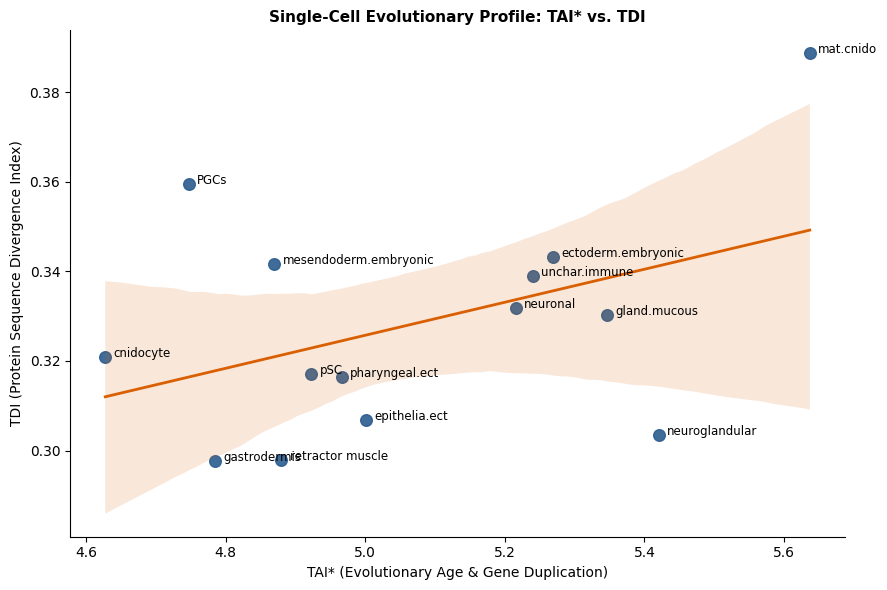

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute protein divergence: Di = 1 - (pident / 100)
master_clean["protein_divergence"] = 1.0 - (master_clean["protein_pident"] / 100.0)
gene_divergence = master_clean.set_index("Orthogroup")["protein_divergence"].dropna()

# 2. Calculate cell-type TDI
tdi_records = []
for ct in nv_pb_cpm.columns:
    expr = nv_pb_cpm[ct]
    shared = expr.index.intersection(gene_divergence.index)
    
    if len(shared) > 0 and expr.loc[shared].sum() > 0:
        tdi_val = (expr.loc[shared] * gene_divergence.loc[shared]).sum() / expr.loc[shared].sum()
        tdi_records.append({"cell_type": ct, "TDI": tdi_val})

tdi_df = pd.DataFrame(tdi_records)

# 3. Detect column name in nv_star (age_score or tai_score) and standardize to 'tai_score'
nv_star_std = nv_star.copy()
if "age_score" in nv_star_std.columns:
    nv_star_std = nv_star_std.rename(columns={"age_score": "tai_score"})
elif "tai" in nv_star_std.columns:
    nv_star_std = nv_star_std.rename(columns={"tai": "tai_score"})

# 4. Build evo_transcriptome_df
evo_transcriptome_df = nv_star_std.merge(tdi_df, on="cell_type")

print("=== Built evo_transcriptome_df ===")
print(evo_transcriptome_df[["cell_type", "tai_score", "TDI"]].sort_values("tai_score", ascending=False).to_string(index=False))

# 5. Plot TAI* vs. TDI
plt.figure(figsize=(9, 6))
ax = sns.regplot(
    data=evo_transcriptome_df,
    x="tai_score",
    y="TDI",
    color="#2b5c8f",
    scatter_kws={"s": 70, "alpha": 0.9},
    line_kws={"color": "#d95f02", "linewidth": 2}
)

for _, row in evo_transcriptome_df.iterrows():
    ax.text(
        row["tai_score"] + 0.012,
        row["TDI"],
        row["cell_type"],
        fontsize=8.5
    )

ax.set_title("Single-Cell Evolutionary Profile: TAI* vs. TDI", fontsize=11, fontweight="bold")
ax.set_xlabel("TAI* (Evolutionary Age & Gene Duplication)")
ax.set_ylabel("TDI (Protein Sequence Divergence Index)")
sns.despine()
plt.tight_layout()
plt.show()

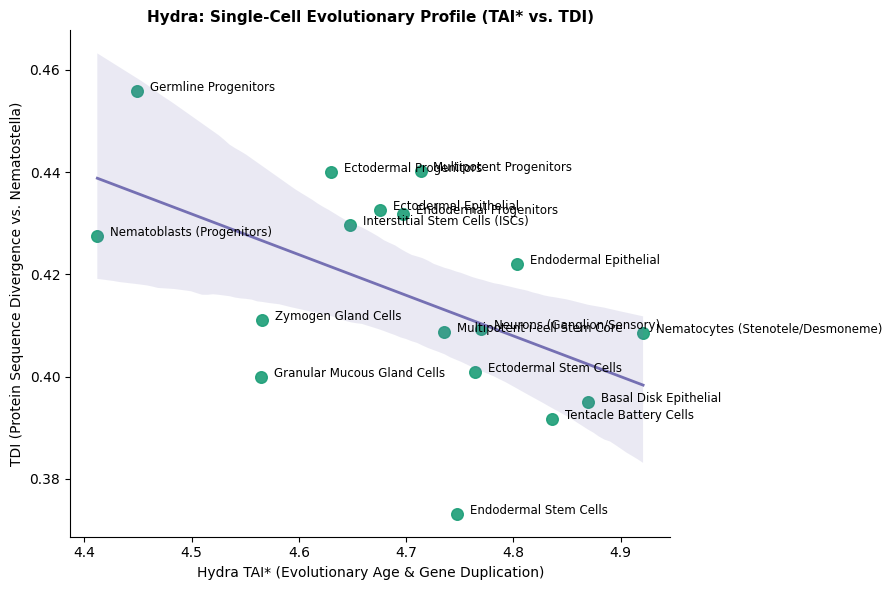

In [48]:
# 1. Compute cell-type TDI for Hydra using Hydra cell-type expression
hy_tdi_records = []
for ct in hy_pb_cpm.columns:
    expr = hy_pb_cpm[ct]
    shared = expr.index.intersection(gene_divergence.index)
    
    if len(shared) > 0 and expr.loc[shared].sum() > 0:
        tdi_val = (expr.loc[shared] * gene_divergence.loc[shared]).sum() / expr.loc[shared].sum()
        hy_tdi_records.append({"cell_type": ct, "TDI": tdi_val})

hy_tdi_df = pd.DataFrame(hy_tdi_records)

# 2. Merge with Hydra TAI*
hy_evo_df = hy_star.rename(columns={"age_score": "tai_score"}).merge(hy_tdi_df, on="cell_type")

# 3. Plot Hydra TAI* vs. TDI
plt.figure(figsize=(9, 6))
ax = sns.regplot(
    data=hy_evo_df, 
    x="tai_score", 
    y="TDI", 
    color="#1b9e77",
    scatter_kws={"s": 70, "alpha": 0.9},
    line_kws={"color": "#7570b3", "linewidth": 2}
)

for _, row in hy_evo_df.iterrows():
    ax.text(row["tai_score"] + 0.012, row["TDI"], row["cell_type"], fontsize=8.5)

ax.set_title("Hydra: Single-Cell Evolutionary Profile (TAI* vs. TDI)", fontsize=11, fontweight="bold")
ax.set_xlabel("Hydra TAI* (Evolutionary Age & Gene Duplication)")
ax.set_ylabel("TDI (Protein Sequence Divergence vs. Nematostella)")
sns.despine()
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define homologous cell type pairs (based on single-cell correlation & marker conservation)
homology_pairs = [
    {"lineage": "Germline", "nvec_cell": "PGCs", "hydra_cell": "Germline Progenitors"},
    {"lineage": "Stinging / Battery", "nvec_cell": "mat.cnido", "hydra_cell": "Tentacle Battery Cells"},
    {"lineage": "Cnidocyte Precursor", "nvec_cell": "cnidocyte", "hydra_cell": "Nematoblasts (Progenitors)"},
    {"lineage": "Contractile / Muscle", "nvec_cell": "retractor muscle", "hydra_cell": "Endodermal Epithelial"},
    {"lineage": "Digestive / Gut", "nvec_cell": "gastrodermis", "hydra_cell": "Endodermal Stem Cells"},
    {"lineage": "Epithelial Outer", "nvec_cell": "epithelia.ect", "hydra_cell": "Ectodermal Epithelial"},
    {"lineage": "Neural", "nvec_cell": "neuronal", "hydra_cell": "Neurons (Ganglion/Sensory)"},
    {"lineage": "Secretory / Gland", "nvec_cell": "gland.mucous", "hydra_cell": "Granular Mucous Gland Cells"},
    {"lineage": "Multipotent / Stem", "nvec_cell": "mesendoderm.embryonic", "hydra_cell": "Interstitial Stem Cells (ISCs)"}
]

homology_df = pd.DataFrame(homology_pairs)

# 2. Lookup TDI values from your previous calculations
nvec_tdi_map = evo_transcriptome_df.set_index("cell_type")["TDI"].to_dict()
hydra_tdi_map = hy_evo_df.set_index("cell_type")["TDI"].to_dict()

homology_df["Nematostella_TDI"] = homology_df["nvec_cell"].map(nvec_tdi_map)
homology_df["Hydra_TDI"] = homology_df["hydra_cell"].map(hydra_tdi_map)

# Compute mean divergence & cross-species gap
homology_df["Mean_TDI"] = (homology_df["Nematostella_TDI"] + homology_df["Hydra_TDI"]) / 2.0
homology_df["Divergence_Delta"] = (homology_df["Hydra_TDI"] - homology_df["Nematostella_TDI"]).abs()
homology_df = homology_df.sort_values("Mean_TDI", ascending=True).reset_index(drop=True)

print(homology_df[["lineage", "nvec_cell", "hydra_cell", "Nematostella_TDI", "Hydra_TDI", "Mean_TDI"]])

                lineage              nvec_cell  \
0       Digestive / Gut           gastrodermis   
1  Contractile / Muscle       retractor muscle   
2     Secretory / Gland           gland.mucous   
3      Epithelial Outer          epithelia.ect   
4                Neural               neuronal   
5   Cnidocyte Precursor              cnidocyte   
6    Multipotent / Stem  mesendoderm.embryonic   
7    Stinging / Battery              mat.cnido   
8              Germline                   PGCs   

                       hydra_cell  Nematostella_TDI  Hydra_TDI  Mean_TDI  
0           Endodermal Stem Cells          0.297697   0.373211  0.335454  
1           Endodermal Epithelial          0.297818   0.422079  0.359948  
2     Granular Mucous Gland Cells          0.330317   0.400021  0.365169  
3           Ectodermal Epithelial          0.306868   0.432615  0.369741  
4      Neurons (Ganglion/Sensory)          0.331878   0.409265  0.370571  
5      Nematoblasts (Progenitors)          0.3208

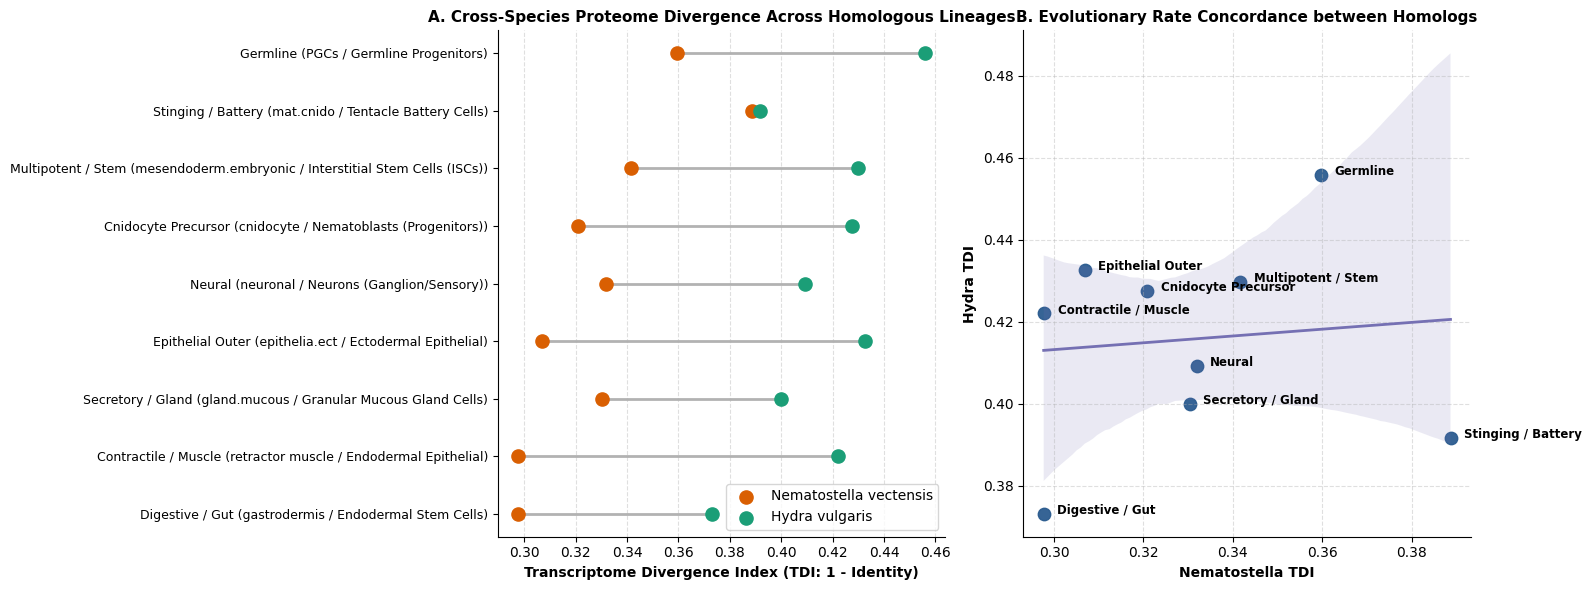

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# Plot 1: Dumbbell Plot (Paired Proteome Divergence per Lineage)
# -------------------------------------------------------------------------
y_indices = np.arange(len(homology_df))

# Draw connecting line between paired species values
for i, row in homology_df.iterrows():
    axes[0].plot(
        [row["Nematostella_TDI"], row["Hydra_TDI"]], 
        [i, i], 
        color="#7f7f7f", 
        linewidth=2, 
        alpha=0.6, 
        zorder=1
    )

# Scatter points for Nematostella and Hydra
axes[0].scatter(
    homology_df["Nematostella_TDI"], y_indices, 
    color="#d95f02", s=90, label="Nematostella vectensis", zorder=2
)
axes[0].scatter(
    homology_df["Hydra_TDI"], y_indices, 
    color="#1b9e77", s=90, label="Hydra vulgaris", zorder=2
)

axes[0].set_yticks(y_indices)
axes[0].set_yticklabels(homology_df["lineage"] + " (" + homology_df["nvec_cell"] + " / " + homology_df["hydra_cell"] + ")", fontsize=9)
axes[0].set_xlabel("Transcriptome Divergence Index (TDI: 1 - Identity)", fontsize=10, fontweight="bold")
axes[0].set_title("A. Cross-Species Proteome Divergence Across Homologous Lineages", fontsize=11, fontweight="bold")
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# -------------------------------------------------------------------------
# Plot 2: Cross-Species Rate Concordance (Nvec TDI vs. Hydra TDI)
# -------------------------------------------------------------------------
sns.regplot(
    data=homology_df,
    x="Nematostella_TDI",
    y="Hydra_TDI",
    ax=axes[1],
    color="#2b5c8f",
    scatter_kws={"s": 80, "alpha": 0.95},
    line_kws={"color": "#7570b3", "linewidth": 2}
)

for _, row in homology_df.iterrows():
    axes[1].text(
        row["Nematostella_TDI"] + 0.003,
        row["Hydra_TDI"],
        row["lineage"],
        fontsize=8.5,
        fontweight="semibold"
    )

axes[1].set_title("B. Evolutionary Rate Concordance between Homologs", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nematostella TDI", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Hydra TDI", fontsize=10, fontweight="bold")
axes[1].grid(linestyle="--", alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

## Enrichment analysison on 1-1 orthologues


In [51]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

def run_functional_enrichment(target_genes, background_genes, gene_to_terms_dict, min_size=3):
    """
    Performs one-tailed Fisher's Exact Test for overrepresentation of functional terms.
    
    Parameters:
    - target_genes: List/Set of query gene IDs (e.g., conserved markers)
    - background_genes: List/Set of all evaluated 1:1 orthologs
    - gene_to_terms_dict: Dict mapping Gene ID -> list/set of GO terms or Pfam domains
    - min_size: Minimum number of genes annotated to the term to consider
    """
    target_set = set(target_genes).intersection(background_genes)
    bg_set = set(background_genes)
    
    # 1. Map term to all genes in background
    term_to_bg = {}
    for g in bg_set:
        terms = gene_to_terms_dict.get(g, [])
        if isinstance(terms, str):
            terms = [terms]
        for t in set(terms):
            term_to_bg.setdefault(t, set()).add(g)
            
    # 2. Run Fisher's Exact Test per term
    results = []
    n_target = len(target_set)
    n_bg = len(bg_set)
    
    for term, bg_term_genes in term_to_bg.items():
        if len(bg_term_genes) < min_size:
            continue
            
        target_term_genes = bg_term_genes.intersection(target_set)
        k = len(target_term_genes)  # Overlap
        M = n_bg                    # Total background genes
        n = len(bg_term_genes)      # Genes in background with term
        N = n_target                # Total query genes
        
        # 2x2 Contingency Table:
        # [[in_target_&_has_term,     in_target_&_no_term],
        #  [not_in_target_&_has_term, not_in_target_&_no_term]]
        table = [
            [k, N - k],
            [n - k, (M - n) - (N - k)]
        ]
        
        odds_ratio, p_val = stats.fisher_exact(table, alternative="greater")
        fold_enrichment = (k / N) / (n / M) if (n / M) > 0 else 0
        
        results.append({
            "term": term,
            "overlap_count": k,
            "target_size": N,
            "bg_term_count": n,
            "bg_size": M,
            "fold_enrichment": fold_enrichment,
            "p_value": p_val,
            "genes": ", ".join(list(target_term_genes))
        })
        
    df_res = pd.DataFrame(results)
    if df_res.empty:
        return df_res
        
    # 3. Benjamini-Hochberg FDR correction
    _, padj, _, _ = multipletests(df_res["p_value"], method="fdr_bh")
    df_res["padj"] = padj
    
    return df_res.sort_values("p_value").reset_index(drop=True)

In [56]:
# Filter for the 89 conserved 1:1 marker genes
conserved_markers = master_clean[master_clean["cell_type_conserved"]].copy()

# Select key reporting columns
summary_table = conserved_markers[[
    "Orthogroup", "Nvec", "Hvul", "Dmel", "Drer",
    "nvec_top_cell_type", "protein_pident", "protein_divergence"
]].sort_values(["nvec_top_cell_type", "protein_pident"], ascending=[True, False])

# View cell-type breakdown of conserved markers
print(f"Total Conserved 1:1 Markers: {len(summary_table)}")
print("\nConserved markers per cell type:")
print(summary_table["nvec_top_cell_type"].value_counts())
print("\nTop conserved markers:")
print(summary_table.head(10).to_string(index=False))

Total Conserved 1:1 Markers: 89

Conserved markers per cell type:
nvec_top_cell_type
PGCs                47
mat.cnido           16
cnidocyte           11
retractor muscle     8
gastrodermis         6
unchar.immune        1
Name: count, dtype: int64

Top conserved markers:
Orthogroup           Nvec           Hvul                        Dmel           Drer nvec_top_cell_type  protein_pident  protein_divergence
 OG0007190 XP_001634291.1 XP_002164433.1                         NaN NP_001002210.1               PGCs            82.6               0.174
 OG0006068 XP_048590713.1 XP_047144887.1                 NP_650128.1 NP_001103584.2               PGCs            78.2               0.218
 OG0005188 XP_001638849.1 XP_047133502.1              NP_001246039.1 NP_001003442.1               PGCs            76.7               0.233
 OG0007770 XP_001638072.3 XP_002165861.1                         NaN XP_005165553.1               PGCs            73.3               0.267
 OG0005670 XP_001638674.1 XP_047

In [57]:
import scipy.stats as stats

# A. Mann-Whitney U test: Are conserved markers significantly more conserved in protein sequence?
conserved_pident = master_clean[master_clean["cell_type_conserved"]]["protein_pident"].dropna()
non_conserved_pident = master_clean[~master_clean["cell_type_conserved"]]["protein_pident"].dropna()

stat, pval = stats.mannwhitneyu(conserved_pident, non_conserved_pident, alternative="greater")
print(f"Mann-Whitney U Test: Conserved vs Non-Conserved Protein Identity")
print(f"Mean Conserved % Identity: {conserved_pident.mean():.2f}%")
print(f"Mean Non-Conserved % Identity: {non_conserved_pident.mean():.2f}%")
print(f"P-value: {pval:.4e}")

# B. Kruskal-Wallis Test: Does sequence identity differ across cell types?
cell_type_groups = [group["protein_pident"].dropna().values for _, group in master_clean.groupby("nvec_top_cell_type")]
kw_stat, kw_pval = stats.kruskal(*cell_type_groups)
print(f"\nKruskal-Wallis Test across Cell Types: P-value = {kw_pval:.4e}")

Mann-Whitney U Test: Conserved vs Non-Conserved Protein Identity
Mean Conserved % Identity: 50.47%
Mean Non-Conserved % Identity: 49.29%
P-value: 2.5910e-01

Kruskal-Wallis Test across Cell Types: P-value = 1.4111e-07


In [60]:
print(adata_nv.obs.columns.tolist())

['sample', 'Partition_ID', 'Cell_State_ID', 'source_batch']


Computing UMAP coordinates...
UMAP coordinates computed successfully!


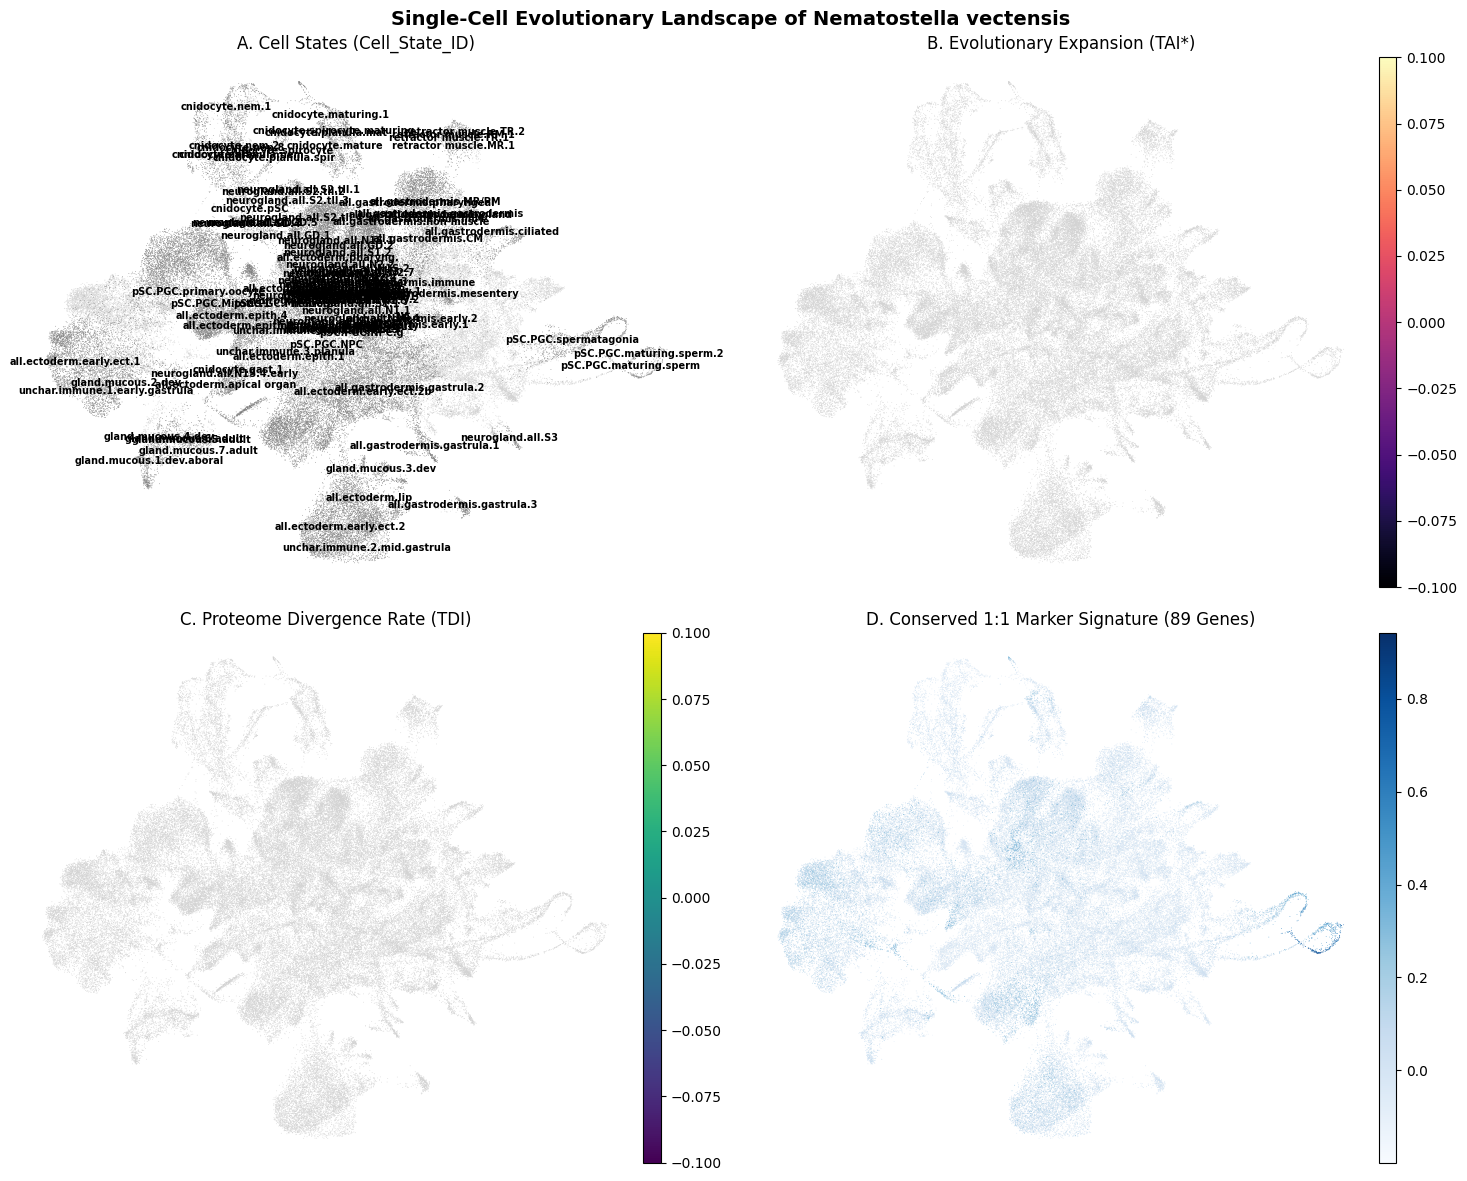

In [68]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute neighborhood graph & UMAP if missing
if "X_umap" not in adata.obsm:
    print("Computing UMAP coordinates...")
    # Run PCA if not present
    if "X_pca" not in adata.obsm:
        # If raw counts, normalize & log-transform first
        if adata.X.max() > 50:
            sc.pp.normalize_total(adata, target_sum=1e4)
            sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
        sc.pp.pca(adata, svd_solver="arpack")
    
    # Compute graph & UMAP
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
    sc.tl.umap(adata)
    print("UMAP coordinates computed successfully!")

# 2. Match NVE Gene IDs and Score Conserved 1:1 Signature
conserved_nve_ids = (
    master_clean[master_clean["cell_type_conserved"]]["nv_atlas_gene_nve"]
    .dropna()
    .astype(str)
    .tolist()
)
valid_genes = [g for g in conserved_nve_ids if g in adata.var_names]

sc.tl.score_genes(
    adata, 
    gene_list=valid_genes, 
    score_name="Conserved_1to1_Score", 
    use_raw=False
)

# 3. Multi-Panel Evolutionary UMAP Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel A: Cell State Annotations
sc.pl.umap(
    adata, 
    color="Cell_State_ID", 
    ax=axes[0, 0], 
    show=False, 
    title="A. Cell States (Cell_State_ID)",
    legend_loc="on data",
    legend_fontsize=7,
    frameon=False
)

# Panel B: TAI* (Paralog Expansion & Evolutionary Age)
sc.pl.umap(
    adata, 
    color="TAI_star", 
    cmap="magma", 
    ax=axes[0, 1], 
    show=False, 
    title="B. Evolutionary Expansion (TAI*)",
    colorbar_loc="right",
    frameon=False
)

# Panel C: TDI (Proteome Divergence Rate vs. Hydra)
sc.pl.umap(
    adata, 
    color="TDI", 
    cmap="viridis", 
    ax=axes[1, 0], 
    show=False, 
    title="C. Proteome Divergence Rate (TDI)",
    colorbar_loc="right",
    frameon=False
)

# Panel D: Conserved 1:1 Marker Signature (PGC Core)
sc.pl.umap(
    adata, 
    color="Conserved_1to1_Score", 
    cmap="Blues", 
    ax=axes[1, 1], 
    show=False, 
    title=f"D. Conserved 1:1 Marker Signature ({len(valid_genes)} Genes)",
    colorbar_loc="right",
    frameon=False
)

plt.suptitle("Single-Cell Evolutionary Landscape of Nematostella vectensis", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

In [69]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

adata = adata_nv.copy()

# ------------------------------------------------------------------------------
# 1. Map Fine Subclusters -> Clean Broad Lineages for Panel A
# ------------------------------------------------------------------------------
def assign_broad_lineage(c_id):
    s = str(c_id).lower()
    if "pgc" in s or "sperm" in s or "oocyte" in s:
        return "Germline / PGCs"
    elif "cnidocyte" in s or "cnido" in s or "nemat" in s:
        return "Cnidocyte Lineage"
    elif "retractor" in s or "muscle" in s:
        return "Retractor Muscle"
    elif "gastro" in s or "endoderm" in s:
        return "Gastrodermis / Gut"
    elif "neuro" in s or "neural" in s:
        return "Neuronal"
    elif "gland" in s or "mucous" in s:
        return "Gland / Secretory"
    elif "ectoderm" in s or "epith" in s:
        return "Ectodermal Epithelia"
    elif "immune" in s:
        return "Immune"
    return "Other / Progenitor"

adata.obs["broad_lineage"] = adata.obs["Cell_State_ID"].apply(assign_broad_lineage)

# ------------------------------------------------------------------------------
# 2. Build Gene-Level Metric Dictionaries
# ------------------------------------------------------------------------------
# Map NVE IDs to phylostratum/duplication age (TAI*) and protein divergence (TDI)
gene_clean = master_clean.dropna(subset=["nv_atlas_gene_nve"]).copy()
gene_clean["nv_atlas_gene_nve"] = gene_clean["nv_atlas_gene_nve"].astype(str)

# Calculate gene-level TAI* = phylostratum_age * log2(1 + n_paralogs)
gene_clean["gene_tai_star"] = gene_clean["phylostratum_age"] * np.log2(1 + gene_clean["n_paralogs_nvec"].fillna(1))

dict_tai = gene_clean.set_index("nv_atlas_gene_nve")["gene_tai_star"].to_dict()
dict_tdi = gene_clean.set_index("nv_atlas_gene_nve")["protein_divergence"].to_dict()

# ------------------------------------------------------------------------------
# 3. Calculate True Single-Cell Evolutionary Scores (scTAI* and scTDI)
# ------------------------------------------------------------------------------
# Find intersecting genes present in adata.var_names
common_tai_genes = [g for g in adata.var_names if g in dict_tai]
common_tdi_genes = [g for g in adata.var_names if g in dict_tdi]

print(f"Scoring scTAI* with {len(common_tai_genes):,} genes")
print(f"Scoring scTDI with {len(common_tdi_genes):,} genes")

# Extract expression submatrices
X_tai = adata[:, common_tai_genes].X
w_tai = np.array([dict_tai[g] for g in common_tai_genes])

X_tdi = adata[:, common_tdi_genes].X
w_tdi = np.array([dict_tdi[g] for g in common_tdi_genes])

# Compute cell-wise weighted averages (handles both sparse & dense arrays)
if sp.issparse(X_tai):
    sum_expr_tai = np.array(X_tai.sum(axis=1)).flatten()
    weighted_tai = np.array(X_tai.dot(w_tai)).flatten()
    
    sum_expr_tdi = np.array(X_tdi.sum(axis=1)).flatten()
    weighted_tdi = np.array(X_tdi.dot(w_tdi)).flatten()
else:
    sum_expr_tai = X_tai.sum(axis=1)
    weighted_tai = X_tai.dot(w_tai)
    
    sum_expr_tdi = X_tdi.sum(axis=1)
    weighted_tdi = X_tdi.dot(w_tdi)

# Avoid divide-by-zero on unexpressed cells
sum_expr_tai[sum_expr_tai == 0] = np.nan
sum_expr_tdi[sum_expr_tdi == 0] = np.nan

adata.obs["scTAI_star"] = weighted_tai / sum_expr_tai
adata.obs["scTDI"] = weighted_tdi / sum_expr_tdi

# ------------------------------------------------------------------------------
# 4. Score Conserved 1:1 Marker Signature (89 Genes)
# ------------------------------------------------------------------------------
conserved_nve_ids = (
    master_clean[master_clean["cell_type_conserved"]]["nv_atlas_gene_nve"]
    .dropna()
    .astype(str)
    .tolist()
)
valid_markers = [g for g in conserved_nve_ids if g in adata.var_names]

sc.tl.score_genes(
    adata, 
    gene_list=valid_markers, 
    score_name="Conserved_1to1_Score", 
    use_raw=False
)

Scoring scTAI* with 2,043 genes
Scoring scTDI with 2,043 genes


Running PCA...
Computing neighborhood graph and UMAP coordinates...
UMAP embedding generated successfully in adata.obsm['X_umap']!


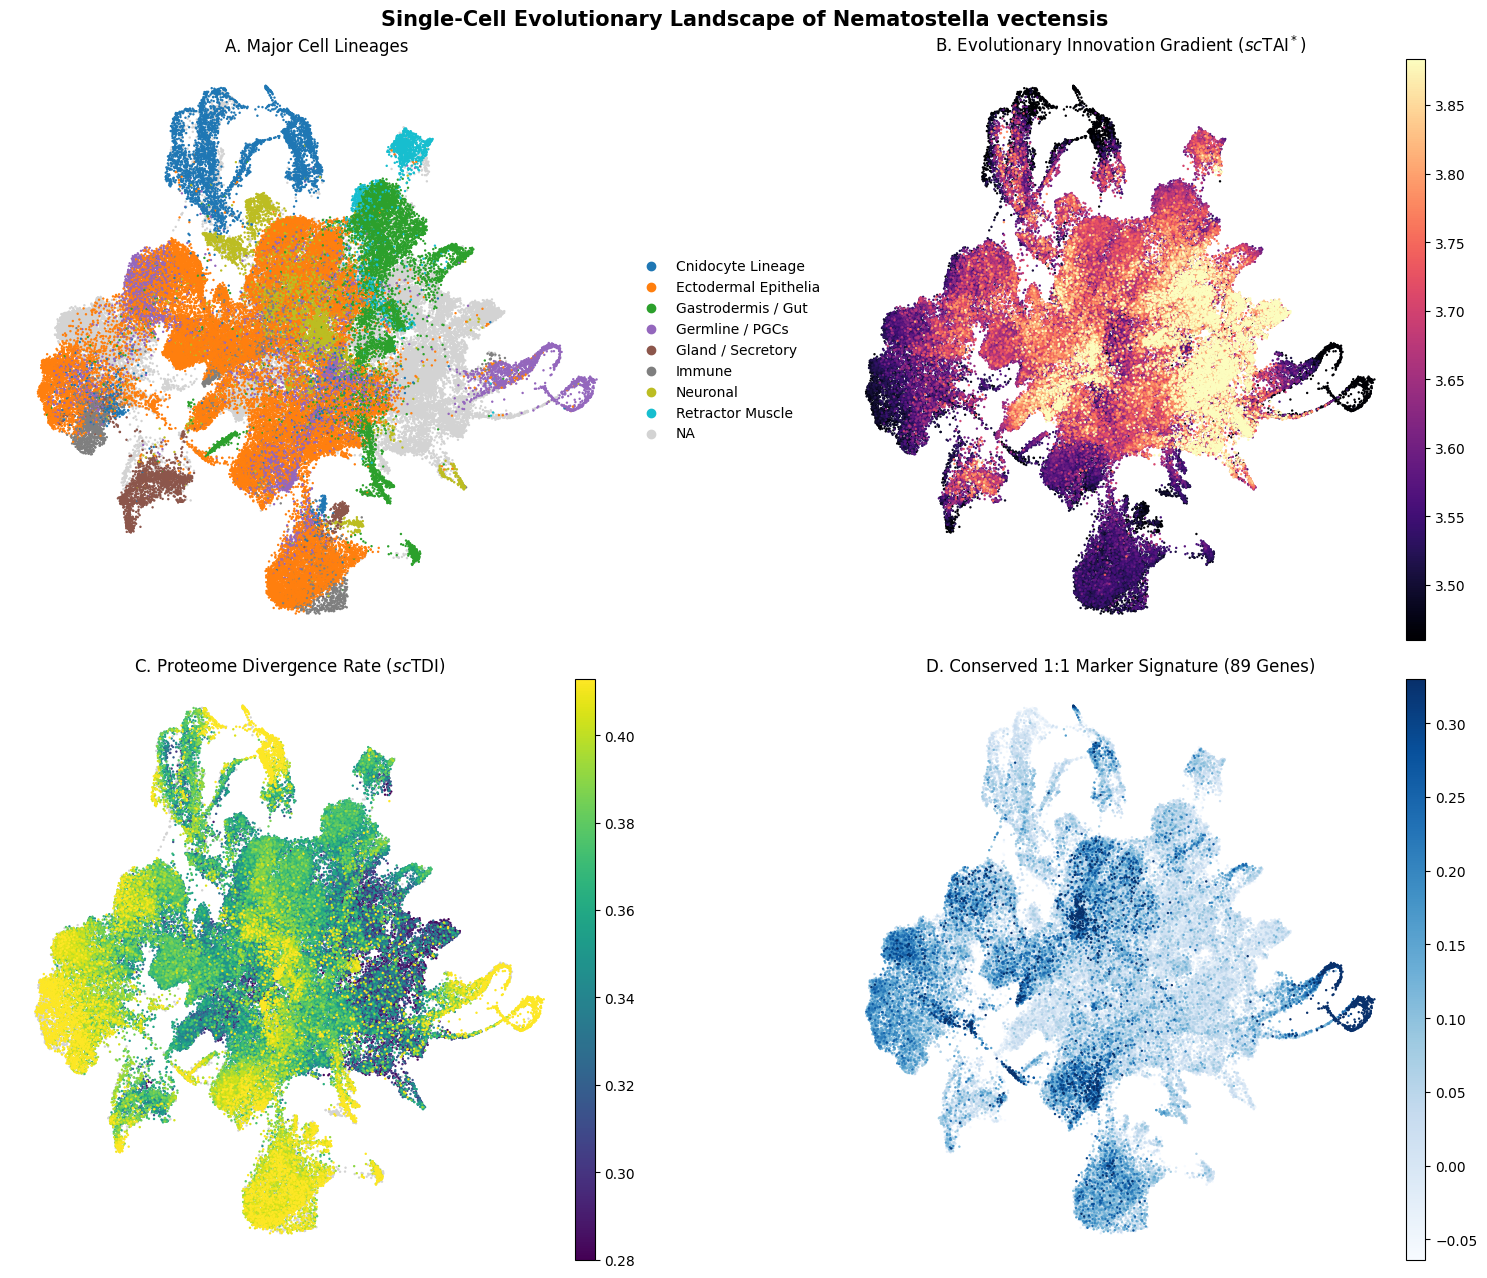

In [71]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPROCESSING & COMPUTE UMAP EMBEDDING
# ==============================================================================
adata = adata_nv.copy()

# Ensure AnnData has normalized/log-transformed values and compute PCA
if "X_pca" not in adata.obsm:
    print("Running PCA...")
    if adata.X.max() > 50:  # Raw count check
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    sc.pp.pca(adata, svd_solver="arpack")

# Compute neighborhood graph and 2D UMAP coordinates
print("Computing neighborhood graph and UMAP coordinates...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
print("UMAP embedding generated successfully in adata.obsm['X_umap']!")

# ==============================================================================
# 2. LINEAGE GROUPING & EVOLUTIONARY FEATURE SCORING
# ==============================================================================
# A. Group fine subclusters into broad lineages
def assign_broad_lineage(c_id):
    s = str(c_id).lower()
    if any(k in s for k in ["pgc", "sperm", "oocyte"]):
        return "Germline / PGCs"
    elif any(k in s for k in ["cnidocyte", "cnido", "nemat"]):
        return "Cnidocyte Lineage"
    elif any(k in s for k in ["retractor", "muscle"]):
        return "Retractor Muscle"
    elif any(k in s for k in ["gastro", "endoderm"]):
        return "Gastrodermis / Gut"
    elif any(k in s for k in ["neuro", "neural"]):
        return "Neuronal"
    elif any(k in s for k in ["gland", "mucous"]):
        return "Gland / Secretory"
    elif any(k in s for k in ["ectoderm", "epith"]):
        return "Ectodermal Epithelia"
    elif "immune" in s:
        return "Immune"
    return "Other / Progenitor"

adata.obs["broad_lineage"] = adata.obs["Cell_State_ID"].apply(assign_broad_lineage)

# B. Build gene-level lookup dictionaries
gene_clean = master_clean.dropna(subset=["nv_atlas_gene_nve"]).copy()
gene_clean["nv_atlas_gene_nve"] = gene_clean["nv_atlas_gene_nve"].astype(str)

# Calculate gene-level TAI* = phylostratum_age * log2(1 + n_paralogs)
gene_clean["gene_tai_star"] = (
    gene_clean["phylostratum_age"] * np.log2(1 + gene_clean["n_paralogs_nvec"].fillna(1))
)

dict_tai = gene_clean.set_index("nv_atlas_gene_nve")["gene_tai_star"].to_dict()
dict_tdi = gene_clean.set_index("nv_atlas_gene_nve")["protein_divergence"].to_dict()

# C. Calculate single-cell scTAI* and scTDI
common_tai_genes = [g for g in adata.var_names if g in dict_tai]
common_tdi_genes = [g for g in adata.var_names if g in dict_tdi]

X_tai = adata[:, common_tai_genes].X
w_tai = np.array([dict_tai[g] for g in common_tai_genes])

X_tdi = adata[:, common_tdi_genes].X
w_tdi = np.array([dict_tdi[g] for g in common_tdi_genes])

if sp.issparse(X_tai):
    sum_expr_tai = np.array(X_tai.sum(axis=1)).flatten()
    weighted_tai = np.array(X_tai.dot(w_tai)).flatten()
    sum_expr_tdi = np.array(X_tdi.sum(axis=1)).flatten()
    weighted_tdi = np.array(X_tdi.dot(w_tdi)).flatten()
else:
    sum_expr_tai = X_tai.sum(axis=1)
    weighted_tai = X_tai.dot(w_tai)
    sum_expr_tdi = X_tdi.sum(axis=1)
    weighted_tdi = X_tdi.dot(w_tdi)

sum_expr_tai[sum_expr_tai == 0] = np.nan
sum_expr_tdi[sum_expr_tdi == 0] = np.nan

adata.obs["scTAI_star"] = weighted_tai / sum_expr_tai
adata.obs["scTDI"] = weighted_tdi / sum_expr_tdi

# D. Score 89 Conserved 1:1 Marker Signature
conserved_nve_ids = (
    master_clean[master_clean["cell_type_conserved"]]["nv_atlas_gene_nve"]
    .dropna()
    .astype(str)
    .tolist()
)
valid_markers = [g for g in conserved_nve_ids if g in adata.var_names]

sc.tl.score_genes(
    adata, 
    gene_list=valid_markers, 
    score_name="Conserved_1to1_Score", 
    use_raw=False
)

# ==============================================================================
# 3. MULTI-PANEL SINGLE-CELL EVOLUTIONARY UMAP
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

# Panel A: Clean Broad Lineages
sc.pl.umap(
    adata, 
    color="broad_lineage", 
    ax=axes[0, 0], 
    show=False, 
    title="A. Major Cell Lineages",
    palette="tab10",
    legend_loc="right margin",
    size=12,
    frameon=False
)

# Panel B: Single-Cell TAI* Gradient
sc.pl.umap(
    adata, 
    color="scTAI_star", 
    cmap="magma", 
    ax=axes[0, 1], 
    show=False, 
    title="B. Evolutionary Innovation Gradient ($sc\\mathrm{TAI}^*$)",
    vmin="p5", vmax="p95",
    size=12,
    frameon=False
)

# Panel C: Single-Cell TDI Divergence Rate
sc.pl.umap(
    adata, 
    color="scTDI", 
    cmap="viridis", 
    ax=axes[1, 0], 
    show=False, 
    title="C. Proteome Divergence Rate ($sc\\mathrm{TDI}$)",
    vmin="p5", vmax="p95",
    size=12,
    frameon=False
)

# Panel D: Conserved 1:1 Marker Signature Score
sc.pl.umap(
    adata, 
    color="Conserved_1to1_Score", 
    cmap="Blues", 
    ax=axes[1, 1], 
    show=False, 
    title=f"D. Conserved 1:1 Marker Signature ({len(valid_markers)} Genes)",
    vmin="p10", vmax="p99",
    size=12,
    frameon=False
)

plt.suptitle("Single-Cell Evolutionary Landscape of Nematostella vectensis", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()